# OBJETIVO ESPECIFICO 2

**Author:** Andres Felipe Sierra

**Objetivo:** Construcción y análisis del modelo LSTM para el cumplimiento del Objetivo específico número 2 del proyecto de grado.

**Apreciaciones:** Este script tiene la implementación de la metodología de investigación del proyecto de grado. Por otro lado, este Script tiene el objetivo de presentar netamente el modelo LSTM del proyecto del objetivo especifico.

## Bussness understanding

Los datos fueron preparados tomando varias bases de datos, se tuvieron en cuenta La cartografía de Colombia, la fronteras agrícolas, los cultivos de Arroz y de Maíz con el objetivo de generalizar a cualquier cultivo, las precipitaciones, la topografía, cuerpos de agua, entre otros.

Si se quiere saber la preparación se invita a observar en los scrips llamados "Preparacion_..." y "Cartografia_Col". Lo anterior permitió la contrucción de una base práctica y completa para esperar resultados positivos.

## Data understanding

Se carga y verifica que el dataset funciona y contiene las variables deseadas, además analizamos lo datos preparados para su manipulación en el modelo.

### Librerias

In [1]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    brier_score_loss
)

### Funciones

In [2]:
def info_data(dat):
    print("Los datos se componen de ", dat.shape, "(FILAS/COLUMAS)")
    dat.info()

In [3]:
def construir_secuencias(data, columnas_features, objetivo, ventana):
    X_list, y_list, meta_list = [], [], []

    for cod, g in data.groupby("codigo_municipio"):
        g = g.sort_values(["anio", "mes"]).reset_index(drop=True)

        Xg = g[columnas_features].values.astype(np.float32)
        yg = g[objetivo].values.astype(np.float32)

        # metadata del mes objetivo
        meta = g[["codigo_municipio", "anio", "mes"]].copy()

        if len(g) < ventana:
            continue

        for i in range(ventana - 1, len(g)):
            X_seq = Xg[i - ventana + 1 : i + 1]
            y_seq = yg[i]

            X_list.append(X_seq)
            y_list.append(y_seq)
            meta_list.append(meta.iloc[i].to_dict())

    X = np.stack(X_list, axis=0) if X_list else np.empty((0, ventana, len(columnas_features)), dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta_df = pd.DataFrame(meta_list)

    return X, y, meta_df

In [4]:
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [5]:
def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

### Exploración de datos

In [6]:
# Ruta del dataset
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/panel_modelo_2010_2024_base.csv"
CARPETA_SALIDA = "salidas_lstm_frecuencia"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

VENTANA = 12
OBJETIVO = "hubo_inundacion_agricola_mes"

In [7]:
# Cargamos el dataset
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")
df["codigo_municipio"] = df["codigo_municipio"].astype(str).str.zfill(5)

df = df.sort_values(["codigo_municipio", "anio", "mes"]).reset_index(drop=True)

In [8]:
# Variables a trabajar
columnas_features = [
    "precipitacion_media_mensual_mm",
    "precipitacion_acumulada_3m_mm",
    "precipitacion_media_3m_mm",
    "percentil_95_precipitacion_municipal_mm",
    "indicador_mes_extremo",
    "altitud_municipio_m",
    "area_municipio_km2",
    "longitud_drenajes_km",
    "densidad_drenaje_km_km2",
    "distancia_drenaje_m",
    "proporcion_humedales",
    "elevacion_media_m",
    "pendiente_media_grados",
    "frontera_agricola_total_ha",
    "area_excluida_legal_ha",
    "proporcion_frontera_agricola",
    "maiz_aptitud_alta_ha",
    "arroz_aptitud_alta_ha",
]

faltantes = [c for c in columnas_features + ["codigo_municipio", "anio", "mes", OBJETIVO] if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas: {faltantes}")

In [9]:
info_data(df)

Los datos se componen de  (199716, 62) (FILAS/COLUMAS)
<class 'pandas.DataFrame'>
RangeIndex: 199716 entries, 0 to 199715
Data columns (total 62 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   codigo_municipio                         199716 non-null  str    
 1   mes                                      199716 non-null  int64  
 2   precipitacion_media_mensual_mm           199360 non-null  float64
 3   anio                                     199716 non-null  int64  
 4   periodo                                  199716 non-null  str    
 5   nombre_municipio                         199716 non-null  str    
 6   codigo_departamento                      199716 non-null  int64  
 7   altitud_municipio_m                      199716 non-null  int64  
 8   area_municipio_km2                       199716 non-null  float64
 9   longitud_drenajes_km                     199716 non-null  f

### Data preparation

In [10]:
# Imputación y escalado
mask_train_filas = df["anio"] <= 2021

medianas = df.loc[mask_train_filas, columnas_features].median()
df[columnas_features] = df[columnas_features].fillna(medianas)

scaler = StandardScaler()
scaler.fit(df.loc[mask_train_filas, columnas_features])

df[columnas_features] = scaler.transform(df[columnas_features])

joblib.dump(scaler, os.path.join(CARPETA_SALIDA, "scaler_lstm.joblib"))

['salidas_lstm_frecuencia\\scaler_lstm.joblib']

Se imputa y se escala debido a que la dividir o hacer split se analizó la tasa positiva dando 0.0 en la prueba

In [11]:
def construir_secuencias_completas(data, columnas_features, objetivo, ventana):
    X_list, y_list, meta_list = [], [], []

    for cod, g in data.groupby("codigo_municipio"):
        g = g.sort_values(["anio", "mes"]).reset_index(drop=True)

        Xg = g[columnas_features].values.astype(np.float32)
        yg = g[objetivo].values.astype(np.float32)

        for i in range(ventana - 1, len(g)):
            X_seq = Xg[i - ventana + 1 : i + 1]
            y_seq = yg[i]

            X_list.append(X_seq)
            y_list.append(y_seq)
            meta_list.append({
                "codigo_municipio": g.loc[i, "codigo_municipio"],
                "anio": int(g.loc[i, "anio"]),
                "mes": int(g.loc[i, "mes"]),
            })

    X = np.stack(X_list, axis=0) if X_list else np.empty((0, ventana, len(columnas_features)), dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta

X_all, y_all, meta_all = construir_secuencias_completas(df, columnas_features, OBJETIVO, VENTANA)

print("Total secuencias:", X_all.shape)

Total secuencias: (187374, 12, 18)


In [12]:
# Split temporal
# normalizacion SOLO con train
idx_train = meta_all["anio"] <= 2021
idx_val = (meta_all["anio"] >= 2022) & (meta_all["anio"] <= 2023)
idx_test = meta_all["anio"] == 2024

X_train, y_train = X_all[idx_train.values], y_all[idx_train.values]
X_val, y_val = X_all[idx_val.values], y_all[idx_val.values]
X_test, y_test = X_all[idx_test.values], y_all[idx_test.values]

meta_train = meta_all.loc[idx_train].reset_index(drop=True)
meta_val = meta_all.loc[idx_val].reset_index(drop=True)
meta_test = meta_all.loc[idx_test].reset_index(drop=True)

print("X_train:", X_train.shape, "tasa positiva:", y_train.mean() if len(y_train) else None)
print("X_val:", X_val.shape, "tasa positiva:", y_val.mean() if len(y_val) else None)
print("X_test:", X_test.shape, "tasa positiva:", y_test.mean() if len(y_test) else None)

np.savez_compressed(
    os.path.join(CARPETA_SALIDA, "dataset_lstm_frecuencia.npz"),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test
)

meta_train.to_csv(os.path.join(CARPETA_SALIDA, "meta_train.csv"), index=False, encoding="utf-8-sig")
meta_val.to_csv(os.path.join(CARPETA_SALIDA, "meta_val.csv"), index=False, encoding="utf-8-sig")
meta_test.to_csv(os.path.join(CARPETA_SALIDA, "meta_test.csv"), index=False, encoding="utf-8-sig")

with open(os.path.join(CARPETA_SALIDA, "columnas_features_lstm.json"), "w", encoding="utf-8") as f:
    json.dump(columnas_features, f, ensure_ascii=False, indent=2)

print("Proceso terminado:", CARPETA_SALIDA)

X_train: (146982, 12, 18) tasa positiva: 0.0033065274
X_val: (26928, 12, 18) tasa positiva: 0.006201723
X_test: (13464, 12, 18) tasa positiva: 0.0054218657
Proceso terminado: salidas_lstm_frecuencia


In [13]:
np.savez_compressed(
    os.path.join(CARPETA_SALIDA, "dataset_lstm_frecuencia.npz"),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test
)

meta_train.to_csv(os.path.join(CARPETA_SALIDA, "meta_train.csv"), index=False, encoding="utf-8-sig")
meta_val.to_csv(os.path.join(CARPETA_SALIDA, "meta_val.csv"), index=False, encoding="utf-8-sig")
meta_test.to_csv(os.path.join(CARPETA_SALIDA, "meta_test.csv"), index=False, encoding="utf-8-sig")

with open(os.path.join(CARPETA_SALIDA, "columnas_features_lstm.json"), "w", encoding="utf-8") as f:
    json.dump(columnas_features, f, ensure_ascii=False, indent=2)

print("Proceso terminado:", CARPETA_SALIDA)

Proceso terminado: salidas_lstm_frecuencia


## Modelado

In [14]:
CARPETA_DATOS = "salidas_lstm_frecuencia"
CARPETA_SALIDA = "modelo_lstm_frecuencia"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-3
PATIENCE = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE) # Se imprime el dispositivo a entrenar

DEVICE: cpu


In [15]:
# Cargamso el nuevo dataset
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_frecuencia.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

Train: (146982, 12, 18) 0.0033065274
Val: (26928, 12, 18) 0.006201723
Test: (13464, 12, 18) 0.0054218657


### Modelo 1

In [16]:
train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

pos_weight: 50.0


In [18]:
# Modelo
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]   # último paso temporal
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(input_size=X_train.shape[2]).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [19]:
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

In [20]:
# ENtrenamiento
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(model.state_dict(), os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm.pt"))
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

Epoch 1 | train_loss=0.4345 | val_loss=0.5677 | val_roc_auc=0.8153 | val_pr_auc=0.0245 | val_f1=0.0513
Epoch 2 | train_loss=0.3947 | val_loss=0.5622 | val_roc_auc=0.8313 | val_pr_auc=0.0301 | val_f1=0.0000
Epoch 3 | train_loss=0.3816 | val_loss=0.5991 | val_roc_auc=0.8280 | val_pr_auc=0.0262 | val_f1=0.0000
Epoch 4 | train_loss=0.3723 | val_loss=0.5594 | val_roc_auc=0.8314 | val_pr_auc=0.0259 | val_f1=0.0583
Epoch 5 | train_loss=0.3665 | val_loss=0.5423 | val_roc_auc=0.8364 | val_pr_auc=0.0283 | val_f1=0.0739
Epoch 6 | train_loss=0.3632 | val_loss=0.6150 | val_roc_auc=0.8265 | val_pr_auc=0.0302 | val_f1=0.0740
Epoch 7 | train_loss=0.3572 | val_loss=0.5542 | val_roc_auc=0.8218 | val_pr_auc=0.0265 | val_f1=0.0582
Epoch 8 | train_loss=0.3445 | val_loss=0.5651 | val_roc_auc=0.8239 | val_pr_auc=0.0264 | val_f1=0.0610
Epoch 9 | train_loss=0.3450 | val_loss=0.5483 | val_roc_auc=0.8292 | val_pr_auc=0.0294 | val_f1=0.0664
Epoch 10 | train_loss=0.3297 | val_loss=0.6072 | val_roc_auc=0.8286 | val

In [21]:
# Evaluacion final
model.load_state_dict(torch.load(os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm.pt"), map_location=DEVICE))

val_final = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final["y_true"], val_final["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))



MEJOR EPOCH: 6
MEJOR VAL PR-AUC: 0.03018293863455864
UMBRAL OPTIMO: 0.5400000000000001

VALIDACION FINAL
loss : 0.615020010717691
roc_auc : 0.8264746244590898
pr_auc : 0.03018293863455864
brier : 0.028785724192857742
precision : 0.05660377358490566
recall : 0.23353293413173654
f1 : 0.0911214953271028
Matriz:
 [[26111   650]
 [  128    39]]

PRUEBA FINAL
loss : 0.40531697103056297
roc_auc : 0.9146871288526438
pr_auc : 0.06709722817838124
brier : 0.024669816717505455
precision : 0.07384615384615385
recall : 0.3287671232876712
f1 : 0.12060301507537688
Matriz:
 [[13090   301]
 [   49    24]]


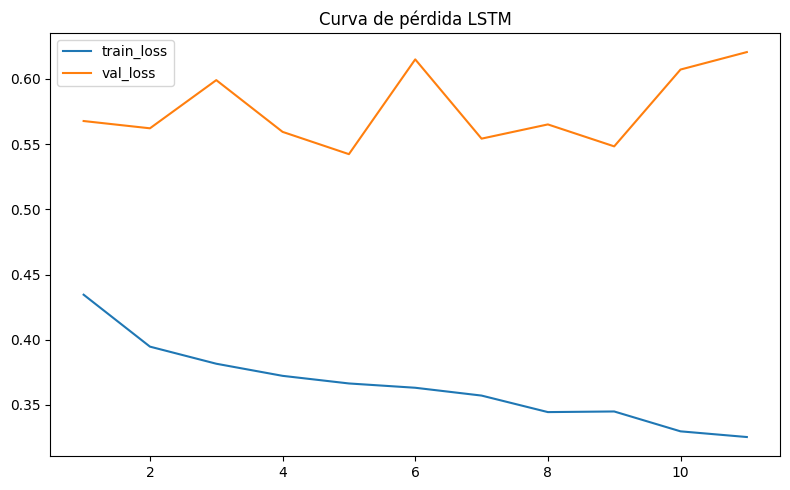


Proceso finalizado: modelo_lstm_frecuencia


In [22]:
pd.DataFrame(history).to_csv(os.path.join(CARPETA_SALIDA, "historial_lstm.csv"), index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
hist = pd.DataFrame(history)
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm.png"), dpi=200)
plt.show()

meta = {
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {k: v for k, v in val_final.items() if k not in ["y_true", "y_prob", "y_pred"]},
    "metricas_prueba_final": {k: v for k, v in test_final.items() if k not in ["y_true", "y_prob", "y_pred"]}
}

with open(os.path.join(CARPETA_SALIDA, "metadatos_lstm.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 1

El modelo 1 encontro la mejor epoca de manera rápida en la sexta epoca con BATCH_SIZE = 64, EPOCHS = 25, LR = 1e-3, PATIENCE = 5; Sin embargo, este resultado se prodía mejorar viendo que se pueden aplicar algunos cambios ya que hay algunas variables que se repiten mes a mes como altitud, area municipal, drenajes, pendiente, frontera agricolla y aptitud, entonces podríamos hacer que LSTM sea para variables dinamicas y un lote de las variables estaticas, también se podría probar una ventana más larga de dos años.

- MEJOR EPOCH: 6
- MEJOR VAL PR-AUC: 0.03018293863455864
- UMBRAL OPTIMO: 0.5400000000000001

- VALIDACION FINAL
- loss : 0.615020010717691
- roc_auc : 0.8264746244590898
- pr_auc : 0.03018293863455864
- brier : 0.028785724192857742
- precision : 0.05660377358490566
- recall : 0.23353293413173654
- f1 : 0.0911214953271028
-Matriz:
 [[26111   650]
 [  128    39]]

- PRUEBA FINAL
- loss : 0.40531697103056297
- roc_auc : 0.9146871288526438
- pr_auc : 0.06709722817838124
- brier : 0.024669816717505455
- precision : 0.07384615384615385
- recall : 0.3287671232876712
- f1 : 0.12060301507537688
- Matriz:
 [[13090   301]
 [   49    24]]

### Modelo 2

In [24]:
# CONFIGURACION
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/panel_modelo_2010_2024_base.csv"
CARPETA_SALIDA = "salidas_lstm_24m_estacional"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

VENTANA = 24
OBJETIVO = "hubo_inundacion_agricola_mes"

# CARGA
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")
df["codigo_municipio"] = df["codigo_municipio"].astype(str).str.zfill(5)

df = df.sort_values(["codigo_municipio", "anio", "mes"]).reset_index(drop=True)

# ESTACIONALIDAD EXPLICITA
df["sin_mes"] = np.sin(2 * np.pi * df["mes"] / 12.0)
df["cos_mes"] = np.cos(2 * np.pi * df["mes"] / 12.0)

# VARIABLES
columnas_features = [
    "precipitacion_media_mensual_mm",
    "precipitacion_acumulada_3m_mm",
    "precipitacion_media_3m_mm",
    "percentil_95_precipitacion_municipal_mm",
    "indicador_mes_extremo",
    "sin_mes",
    "cos_mes",
    "altitud_municipio_m",
    "area_municipio_km2",
    "longitud_drenajes_km",
    "densidad_drenaje_km_km2",
    "distancia_drenaje_m",
    "proporcion_humedales",
    "elevacion_media_m",
    "pendiente_media_grados",
    "frontera_agricola_total_ha",
    "area_excluida_legal_ha",
    "proporcion_frontera_agricola",
    "maiz_aptitud_alta_ha",
    "arroz_aptitud_alta_ha",
]

faltantes = [c for c in columnas_features + ["codigo_municipio", "anio", "mes", OBJETIVO] if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas: {faltantes}")

# IMPUTACION Y ESCALADO
# SOLO CON TRAIN POR FECHA OBJETIVO
mask_train_filas = df["anio"] <= 2021

medianas = df.loc[mask_train_filas, columnas_features].median()
df[columnas_features] = df[columnas_features].fillna(medianas)

scaler = StandardScaler()
scaler.fit(df.loc[mask_train_filas, columnas_features])

df[columnas_features] = scaler.transform(df[columnas_features])

joblib.dump(scaler, os.path.join(CARPETA_SALIDA, "scaler_lstm_24m_estacional.joblib"))

# CONSTRUIR SECUENCIAS SOBRE TODA LA SERIE
def construir_secuencias_completas(data, columnas_features, objetivo, ventana):
    X_list, y_list, meta_list = [], [], []

    for cod, g in data.groupby("codigo_municipio"):
        g = g.sort_values(["anio", "mes"]).reset_index(drop=True)

        Xg = g[columnas_features].values.astype(np.float32)
        yg = g[objetivo].values.astype(np.float32)

        for i in range(ventana - 1, len(g)):
            X_seq = Xg[i - ventana + 1 : i + 1]
            y_seq = yg[i]

            X_list.append(X_seq)
            y_list.append(y_seq)
            meta_list.append({
                "codigo_municipio": g.loc[i, "codigo_municipio"],
                "anio": int(g.loc[i, "anio"]),
                "mes": int(g.loc[i, "mes"]),
            })

    X = np.stack(X_list, axis=0) if X_list else np.empty((0, ventana, len(columnas_features)), dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta

X_all, y_all, meta_all = construir_secuencias_completas(df, columnas_features, OBJETIVO, VENTANA)

print("Total secuencias:", X_all.shape)

# SPLIT SEGUN FECHA DEL TARGET
idx_train = meta_all["anio"] <= 2021
idx_val = (meta_all["anio"] >= 2022) & (meta_all["anio"] <= 2023)
idx_test = meta_all["anio"] == 2024

X_train, y_train = X_all[idx_train.values], y_all[idx_train.values]
X_val, y_val = X_all[idx_val.values], y_all[idx_val.values]
X_test, y_test = X_all[idx_test.values], y_all[idx_test.values]

meta_train = meta_all.loc[idx_train].reset_index(drop=True)
meta_val = meta_all.loc[idx_val].reset_index(drop=True)
meta_test = meta_all.loc[idx_test].reset_index(drop=True)

print("X_train:", X_train.shape, "tasa positiva:", y_train.mean() if len(y_train) else None)
print("X_val:", X_val.shape, "tasa positiva:", y_val.mean() if len(y_val) else None)
print("X_test:", X_test.shape, "tasa positiva:", y_test.mean() if len(y_test) else None)

np.savez_compressed(
    os.path.join(CARPETA_SALIDA, "dataset_lstm_24m_estacional.npz"),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test
)

meta_train.to_csv(os.path.join(CARPETA_SALIDA, "meta_train.csv"), index=False, encoding="utf-8-sig")
meta_val.to_csv(os.path.join(CARPETA_SALIDA, "meta_val.csv"), index=False, encoding="utf-8-sig")
meta_test.to_csv(os.path.join(CARPETA_SALIDA, "meta_test.csv"), index=False, encoding="utf-8-sig")

with open(os.path.join(CARPETA_SALIDA, "columnas_features_lstm_24m_estacional.json"), "w", encoding="utf-8") as f:
    json.dump(columnas_features, f, ensure_ascii=False, indent=2)

print("Proceso terminado:", CARPETA_SALIDA)

Total secuencias: (173910, 24, 20)
X_train: (133518, 24, 20) tasa positiva: 0.0032579878
X_val: (26928, 24, 20) tasa positiva: 0.006201723
X_test: (13464, 24, 20) tasa positiva: 0.0054218657
Proceso terminado: salidas_lstm_24m_estacional


DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.4056 | val_loss=0.5791 | val_roc_auc=0.8058 | val_pr_auc=0.0261 | val_f1=0.0619
Epoch 2 | train_loss=0.3682 | val_loss=0.5544 | val_roc_auc=0.8269 | val_pr_auc=0.0305 | val_f1=0.0640
Epoch 3 | train_loss=0.3542 | val_loss=0.5455 | val_roc_auc=0.8286 | val_pr_auc=0.0322 | val_f1=0.0590
Epoch 4 | train_loss=0.3511 | val_loss=0.5564 | val_roc_auc=0.8284 | val_pr_auc=0.0289 | val_f1=0.0681
Epoch 5 | train_loss=0.3383 | val_loss=0.5910 | val_roc_auc=0.8343 | val_pr_auc=0.0347 | val_f1=0.0867
Epoch 6 | train_loss=0.3313 | val_loss=0.5704 | val_roc_auc=0.8226 | val_pr_auc=0.0276 | val_f1=0.0673
Epoch 7 | train_loss=0.3243 | val_loss=0.6300 | val_roc_auc=0.8093 | val_pr_auc=0.0367 | val_f1=0.0910
Epoch 8 | train_loss=0.3204 | val_loss=0.5971 | val_roc_auc=0.8205 | val_pr_auc=0.0327 | val_f1=0.0716
Epoch 9 | train_loss=0.3086 | val_loss=0.6

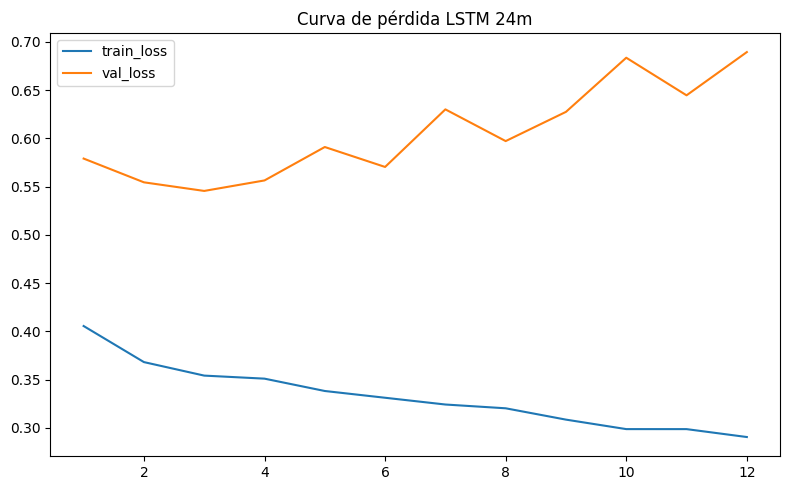


Proceso finalizado: modelo_lstm_24m_estacional


In [25]:
# CONFIGURACION
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-3
PATIENCE = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

# CARGA
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# DATASET
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# POS_WEIGHT
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# MODELO LSTM MAS SIMPLE
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(input_size=X_train.shape[2]).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# FUNCIONES
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# ENTRENAMIENTO
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(model.state_dict(), os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m.pt"))
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# EVALUACION FINAL

model.load_state_dict(torch.load(os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m.pt"), map_location=DEVICE))

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# GUARDAR
hist = pd.DataFrame(history)
hist.to_csv(os.path.join(CARPETA_SALIDA, "historial_lstm_24m.csv"), index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m.png"), dpi=200)
plt.show()

meta = {
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {k: v for k, v in val_final.items() if k not in ["y_true", "y_prob", "y_pred"]},
    "metricas_prueba_final": {k: v for k, v in test_final.items() if k not in ["y_true", "y_prob", "y_pred"]}
}

with open(os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Apreciaciones del modelo 2, este modelo mejoró con respecto al anterior mejorando las metricas de evaluación, por ejemplo aumento el recall a 0.3425 y el f1 a 0.12.

Ahora pasaremos a un modelo GRU de 24 meses con estacionalidad, esto porque suele rendir parecido al modelo LSTM funcionando con menos parametros.

### Resultado 2

PRUEBA FINAL
- loss : 0.43366503671376627
- roc_auc : 0.89573553286147
- pr_auc : 0.09274647947276594
- brier : 0.02487325482070446
- precision : 0.08250825082508251
- recall : 0.3424657534246575
- f1 : 0.13297872340425532

### Modelo 3

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.4029 | val_loss=0.6239 | val_roc_auc=0.8062 | val_pr_auc=0.0279 | val_f1=0.0432
Epoch 2 | train_loss=0.3670 | val_loss=0.5634 | val_roc_auc=0.8189 | val_pr_auc=0.0274 | val_f1=0.0598
Epoch 3 | train_loss=0.3589 | val_loss=0.5774 | val_roc_auc=0.8080 | val_pr_auc=0.0272 | val_f1=0.0590
Epoch 4 | train_loss=0.3520 | val_loss=0.5623 | val_roc_auc=0.8218 | val_pr_auc=0.0298 | val_f1=0.0625
Epoch 5 | train_loss=0.3428 | val_loss=0.5488 | val_roc_auc=0.8378 | val_pr_auc=0.0306 | val_f1=0.0704
Epoch 6 | train_loss=0.3392 | val_loss=0.5743 | val_roc_auc=0.8303 | val_pr_auc=0.0296 | val_f1=0.0676
Epoch 7 | train_loss=0.3322 | val_loss=0.5477 | val_roc_auc=0.8378 | val_pr_auc=0.0310 | val_f1=0.0616
Epoch 8 | train_loss=0.3234 | val_loss=0.5770 | val_roc_auc=0.8293 | val_pr_auc=0.0301 | val_f1=0.0620
Epoch 9 | train_loss=0.3166 | val_loss=0.5

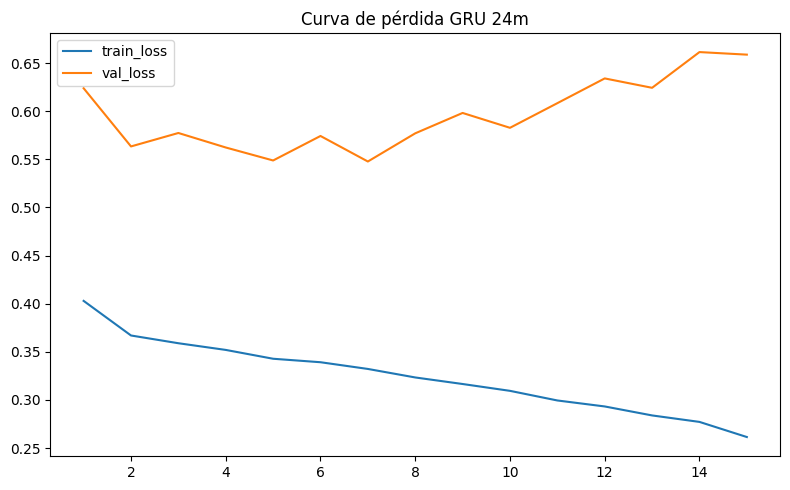


Proceso finalizado: modelo_gru_24m_estacional


In [26]:
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_gru_24m_estacional"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-3
PATIENCE = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO GRU
# =========================================================
class ModeloGRU(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        h = out[:, -1, :]   # último paso temporal
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloGRU(input_size=X_train.shape[2]).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(model.state_dict(), os.path.join(CARPETA_SALIDA, "mejor_modelo_gru_24m.pt"))
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(torch.load(os.path.join(CARPETA_SALIDA, "mejor_modelo_gru_24m.pt"), map_location=DEVICE))

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(os.path.join(CARPETA_SALIDA, "historial_gru_24m.csv"), index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida GRU 24m")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_gru_24m.png"), dpi=200)
plt.show()

meta = {
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {k: v for k, v in val_final.items() if k not in ["y_true", "y_prob", "y_pred"]},
    "metricas_prueba_final": {k: v for k, v in test_final.items() if k not in ["y_true", "y_prob", "y_pred"]}
}

with open(os.path.join(CARPETA_SALIDA, "metadatos_gru_24m.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Apreciaciones del modelo 3, este modelo no supero al LSTM 24m (dos años) por los siguientes resultados: 

Validación

- LSTM 24m: PR-AUC = 0.0367, F1 = 0.1137, Recall = 0.2874
- GRU 24m: PR-AUC = 0.0356, F1 = 0.0835, Recall = 0.1377

Prueba 2024

- LSTM 24m: PR-AUC = 0.0927, F1 = 0.1330, Precision = 0.0825, Recall = 0.3425
- GRU 24m: PR-AUC = 0.0858, F1 = 0.1172, Precision = 0.0843, Recall = 0.1918

El gru tiene una precision parecida, pero pierde mucho recall, por lo que baja el F1 y AUC, por ahora el mejor modelo es el 2.

### Resultado 3

- BATCH_SIZE = 64
- EPOCHS = 25
- LR = 1e-3
- PATIENCE = 5

PRUEBA FINAL
- loss : 0.4185798440428707
- roc_auc : 0.9035009201641258
- pr_auc : 0.08577490632179231
- brier : 0.02727554365992546
- precision : 0.08433734939759036
- recall : 0.1917808219178082
- f1 : 0.11715481171548117

### Modelo 4

Ahora se probara con un modelo híbrido de LSTM con MLP que cada uno se caracteriza por algo en particular, el LSTM se usa con variables dinamicas y el MLP para variables estaticas lo que puede mejorar la sinergía ya que el primero aprende con memoria temporal y el segundo aprende del contexto estructural.

In [27]:
# =========================================================
# CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/panel_modelo_2010_2024_base.csv"
CARPETA_SALIDA = "salidas_lstm_hibrido_24m"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

VENTANA = 24
OBJETIVO = "hubo_inundacion_agricola_mes"

# =========================================================
# CARGA
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")
df["codigo_municipio"] = df["codigo_municipio"].astype(str).str.zfill(5)

df = df.sort_values(["codigo_municipio", "anio", "mes"]).reset_index(drop=True)

# =========================================================
# ESTACIONALIDAD EXPLICITA
# =========================================================
df["sin_mes"] = np.sin(2 * np.pi * df["mes"] / 12.0)
df["cos_mes"] = np.cos(2 * np.pi * df["mes"] / 12.0)

# =========================================================
# VARIABLES DINAMICAS Y ESTATICAS
# =========================================================
columnas_dinamicas = [
    "precipitacion_media_mensual_mm",
    "precipitacion_acumulada_3m_mm",
    "precipitacion_media_3m_mm",
    "percentil_95_precipitacion_municipal_mm",
    "indicador_mes_extremo",
    "sin_mes",
    "cos_mes",
]

columnas_estaticas = [
    "altitud_municipio_m",
    "area_municipio_km2",
    "longitud_drenajes_km",
    "densidad_drenaje_km_km2",
    "distancia_drenaje_m",
    "proporcion_humedales",
    "elevacion_media_m",
    "pendiente_media_grados",
    "frontera_agricola_total_ha",
    "area_excluida_legal_ha",
    "proporcion_frontera_agricola",
    "maiz_aptitud_alta_ha",
    "arroz_aptitud_alta_ha",
]

columnas_requeridas = (
    columnas_dinamicas
    + columnas_estaticas
    + ["codigo_municipio", "anio", "mes", OBJETIVO]
)

faltantes = [c for c in columnas_requeridas if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas: {faltantes}")

# =========================================================
# IMPUTACION Y ESCALADO
# SOLO CON TRAIN POR FECHA OBJETIVO
# =========================================================
mask_train_filas = df["anio"] <= 2021

medianas_dyn = df.loc[mask_train_filas, columnas_dinamicas].median()
medianas_est = df.loc[mask_train_filas, columnas_estaticas].median()

df[columnas_dinamicas] = df[columnas_dinamicas].fillna(medianas_dyn)
df[columnas_estaticas] = df[columnas_estaticas].fillna(medianas_est)

scaler_dyn = StandardScaler()
scaler_est = StandardScaler()

scaler_dyn.fit(df.loc[mask_train_filas, columnas_dinamicas])
scaler_est.fit(df.loc[mask_train_filas, columnas_estaticas])

df[columnas_dinamicas] = scaler_dyn.transform(df[columnas_dinamicas])
df[columnas_estaticas] = scaler_est.transform(df[columnas_estaticas])

joblib.dump(scaler_dyn, os.path.join(CARPETA_SALIDA, "scaler_dinamicas.joblib"))
joblib.dump(scaler_est, os.path.join(CARPETA_SALIDA, "scaler_estaticas.joblib"))

# =========================================================
# CONSTRUIR SECUENCIAS
# =========================================================
def construir_secuencias_hibridas(data, columnas_dinamicas, columnas_estaticas, objetivo, ventana):
    X_dyn_list, X_est_list, y_list, meta_list = [], [], [], []

    for cod, g in data.groupby("codigo_municipio"):
        g = g.sort_values(["anio", "mes"]).reset_index(drop=True)

        X_dyn_g = g[columnas_dinamicas].values.astype(np.float32)
        X_est_g = g[columnas_estaticas].values.astype(np.float32)
        y_g = g[objetivo].values.astype(np.float32)

        for i in range(ventana - 1, len(g)):
            X_dyn_seq = X_dyn_g[i - ventana + 1 : i + 1]
            X_est = X_est_g[i]  # estáticas del mes objetivo
            y_val = y_g[i]

            X_dyn_list.append(X_dyn_seq)
            X_est_list.append(X_est)
            y_list.append(y_val)
            meta_list.append({
                "codigo_municipio": g.loc[i, "codigo_municipio"],
                "anio": int(g.loc[i, "anio"]),
                "mes": int(g.loc[i, "mes"]),
            })

    X_dyn = np.stack(X_dyn_list, axis=0) if X_dyn_list else np.empty((0, ventana, len(columnas_dinamicas)), dtype=np.float32)
    X_est = np.stack(X_est_list, axis=0) if X_est_list else np.empty((0, len(columnas_estaticas)), dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X_dyn, X_est, y, meta

X_dyn_all, X_est_all, y_all, meta_all = construir_secuencias_hibridas(
    df,
    columnas_dinamicas,
    columnas_estaticas,
    OBJETIVO,
    VENTANA
)

print("Total secuencias dinámicas:", X_dyn_all.shape)
print("Total secuencias estáticas:", X_est_all.shape)

# =========================================================
# SPLIT SEGUN FECHA DEL TARGET
# =========================================================
idx_train = meta_all["anio"] <= 2021
idx_val = (meta_all["anio"] >= 2022) & (meta_all["anio"] <= 2023)
idx_test = meta_all["anio"] == 2024

X_dyn_train, X_est_train, y_train = X_dyn_all[idx_train.values], X_est_all[idx_train.values], y_all[idx_train.values]
X_dyn_val, X_est_val, y_val = X_dyn_all[idx_val.values], X_est_all[idx_val.values], y_all[idx_val.values]
X_dyn_test, X_est_test, y_test = X_dyn_all[idx_test.values], X_est_all[idx_test.values], y_all[idx_test.values]

meta_train = meta_all.loc[idx_train].reset_index(drop=True)
meta_val = meta_all.loc[idx_val].reset_index(drop=True)
meta_test = meta_all.loc[idx_test].reset_index(drop=True)

print("X_dyn_train:", X_dyn_train.shape, "| X_est_train:", X_est_train.shape, "| tasa positiva:", y_train.mean() if len(y_train) else None)
print("X_dyn_val:", X_dyn_val.shape, "| X_est_val:", X_est_val.shape, "| tasa positiva:", y_val.mean() if len(y_val) else None)
print("X_dyn_test:", X_dyn_test.shape, "| X_est_test:", X_est_test.shape, "| tasa positiva:", y_test.mean() if len(y_test) else None)

np.savez_compressed(
    os.path.join(CARPETA_SALIDA, "dataset_lstm_hibrido_24m.npz"),
    X_dyn_train=X_dyn_train,
    X_est_train=X_est_train,
    y_train=y_train,
    X_dyn_val=X_dyn_val,
    X_est_val=X_est_val,
    y_val=y_val,
    X_dyn_test=X_dyn_test,
    X_est_test=X_est_test,
    y_test=y_test
)

meta_train.to_csv(os.path.join(CARPETA_SALIDA, "meta_train.csv"), index=False, encoding="utf-8-sig")
meta_val.to_csv(os.path.join(CARPETA_SALIDA, "meta_val.csv"), index=False, encoding="utf-8-sig")
meta_test.to_csv(os.path.join(CARPETA_SALIDA, "meta_test.csv"), index=False, encoding="utf-8-sig")

with open(os.path.join(CARPETA_SALIDA, "columnas_dinamicas.json"), "w", encoding="utf-8") as f:
    json.dump(columnas_dinamicas, f, ensure_ascii=False, indent=2)

with open(os.path.join(CARPETA_SALIDA, "columnas_estaticas.json"), "w", encoding="utf-8") as f:
    json.dump(columnas_estaticas, f, ensure_ascii=False, indent=2)

print("Proceso terminado:", CARPETA_SALIDA)

Total secuencias dinámicas: (173910, 24, 7)
Total secuencias estáticas: (173910, 13)
X_dyn_train: (133518, 24, 7) | X_est_train: (133518, 13) | tasa positiva: 0.0032579878
X_dyn_val: (26928, 24, 7) | X_est_val: (26928, 13) | tasa positiva: 0.006201723
X_dyn_test: (13464, 24, 7) | X_est_test: (13464, 13) | tasa positiva: 0.0054218657
Proceso terminado: salidas_lstm_hibrido_24m


DEVICE: cpu
Train dinámico: (133518, 24, 7) | estático: (133518, 13) | tasa positiva: 0.0032579878
Val dinámico: (26928, 24, 7) | estático: (26928, 13) | tasa positiva: 0.006201723
Test dinámico: (13464, 24, 7) | estático: (13464, 13) | tasa positiva: 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.4046 | val_loss=0.5932 | val_roc_auc=0.8133 | val_pr_auc=0.0327 | val_f1=0.0597
Epoch 2 | train_loss=0.3712 | val_loss=0.5604 | val_roc_auc=0.8216 | val_pr_auc=0.0320 | val_f1=0.0629
Epoch 3 | train_loss=0.3644 | val_loss=0.5560 | val_roc_auc=0.8297 | val_pr_auc=0.0320 | val_f1=0.0642
Epoch 4 | train_loss=0.3552 | val_loss=0.5475 | val_roc_auc=0.8301 | val_pr_auc=0.0324 | val_f1=0.0633
Epoch 5 | train_loss=0.3513 | val_loss=0.5680 | val_roc_auc=0.8415 | val_pr_auc=0.0317 | val_f1=0.0603
Epoch 6 | train_loss=0.3516 | val_loss=0.5937 | val_roc_auc=0.8118 | val_pr_auc=0.0291 | val_f1=0.0639
Early stopping

MEJOR EPOCH: 1
MEJOR VAL PR-AUC: 0.03265495206066386
UMBRAL OPTIMO: 0.43000000000000

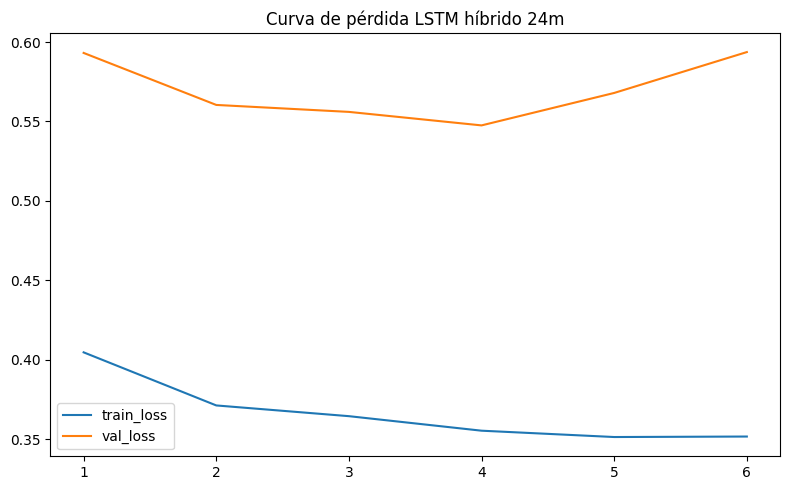


Proceso finalizado: modelo_lstm_hibrido_24m


In [28]:
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_hibrido_24m"
CARPETA_SALIDA = "modelo_lstm_hibrido_24m"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-3
PATIENCE = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_hibrido_24m.npz"))

X_dyn_train = data["X_dyn_train"]
X_est_train = data["X_est_train"]
y_train = data["y_train"]

X_dyn_val = data["X_dyn_val"]
X_est_val = data["X_est_val"]
y_val = data["y_val"]

X_dyn_test = data["X_dyn_test"]
X_est_test = data["X_est_test"]
y_test = data["y_test"]

print("Train dinámico:", X_dyn_train.shape, "| estático:", X_est_train.shape, "| tasa positiva:", y_train.mean())
print("Val dinámico:", X_dyn_val.shape, "| estático:", X_est_val.shape, "| tasa positiva:", y_val.mean())
print("Test dinámico:", X_dyn_test.shape, "| estático:", X_est_test.shape, "| tasa positiva:", y_test.mean())

# =========================================================
# DATASET
# =========================================================
class DatasetHibrido(Dataset):
    def __init__(self, X_dyn, X_est, y):
        self.X_dyn = torch.tensor(X_dyn, dtype=torch.float32)
        self.X_est = torch.tensor(X_est, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_dyn[idx], self.X_est[idx], self.y[idx]

train_ds = DatasetHibrido(X_dyn_train, X_est_train, y_train)
val_ds = DatasetHibrido(X_dyn_val, X_est_val, y_val)
test_ds = DatasetHibrido(X_dyn_test, X_est_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO HIBRIDO
# =========================================================
class ModeloLSTMHibrido(nn.Module):
    def __init__(
        self,
        input_dyn,
        input_est,
        hidden_size=32,
        num_layers=1,
        dropout_lstm=0.1
    ):
        super().__init__()

        # Rama temporal
        self.lstm = nn.LSTM(
            input_size=input_dyn,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout_lstm
        )

        # Rama estática
        self.mlp_est = nn.Sequential(
            nn.Linear(input_est, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # Cabeza final
        self.head = nn.Sequential(
            nn.Linear(hidden_size + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x_dyn, x_est):
        out, _ = self.lstm(x_dyn)
        h_dyn = out[:, -1, :]       # último paso temporal

        h_est = self.mlp_est(x_est)

        h = torch.cat([h_dyn, h_est], dim=1)
        logits = self.head(h).squeeze(1)
        return logits

model = ModeloLSTMHibrido(
    input_dyn=X_dyn_train.shape[2],
    input_est=X_est_train.shape[1],
    hidden_size=32,
    num_layers=1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for x_dyn, x_est, yb in loader:
            x_dyn = x_dyn.to(DEVICE)
            x_est = x_est.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(x_dyn, x_est)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for x_dyn, x_est, yb in train_dl:
        x_dyn = x_dyn.to(DEVICE)
        x_est = x_est.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x_dyn, x_est)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(model.state_dict(), os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_hibrido.pt"))
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(torch.load(os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_hibrido.pt"), map_location=DEVICE))

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(os.path.join(CARPETA_SALIDA, "historial_lstm_hibrido.csv"), index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM híbrido 24m")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_hibrido.png"), dpi=200)
plt.show()

meta = {
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {k: v for k, v in val_final.items() if k not in ["y_true", "y_prob", "y_pred"]},
    "metricas_prueba_final": {k: v for k, v in test_final.items() if k not in ["y_true", "y_prob", "y_pred"]}
}

with open(os.path.join(CARPETA_SALIDA, "metadatos_lstm_hibrido.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Consideraciones del modelo 4, este modelo no mejoró con respecto a los modelos anteriores, es decir, el modelo 3 LSTM 24 ha sido el mejor hasta el momento comparandose:

Mejor modelo hasta ahora: 

- LSTM 24m estacional
En prueba 2024:
ROC-AUC = 0.8957
PR-AUC = 0.0927
Precision = 0.0825
Recall = 0.3425
F1 = 0.1330

- LSTM híbrido 24m
En prueba 2024:

ROC-AUC = 0.9011
PR-AUC = 0.0649
Precision = 0.0613
Recall = 0.6438
F1 = 0.1119

### Resultado 4

- BATCH_SIZE = 64
- EPOCHS = 25
- LR = 1e-3
- PATIENCE = 5

PRUEBA FINAL
- loss : 0.4256749977909417
- roc_auc : 0.901143990596833
- pr_auc : 0.06491335346627859
- brier : 0.02927696518599987
- precision : 0.061277705345501955
- recall : 0.6438356164383562
- f1 : 0.11190476190476191

### Modelo 5

Ahora probaremos con un modelo LSTM con atención temporal

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.4422 | val_loss=0.6917 | val_roc_auc=0.7263 | val_pr_auc=0.0172 | val_f1=0.0000
Epoch 2 | train_loss=0.4176 | val_loss=0.7095 | val_roc_auc=0.7296 | val_pr_auc=0.0209 | val_f1=0.0000
Epoch 3 | train_loss=0.4012 | val_loss=0.6859 | val_roc_auc=0.7219 | val_pr_auc=0.0208 | val_f1=0.0000
Epoch 4 | train_loss=0.3930 | val_loss=0.7552 | val_roc_auc=0.7077 | val_pr_auc=0.0206 | val_f1=0.0431
Epoch 5 | train_loss=0.3833 | val_loss=0.6947 | val_roc_auc=0.7014 | val_pr_auc=0.0243 | val_f1=0.0615
Epoch 6 | train_loss=0.3806 | val_loss=0.6797 | val_roc_auc=0.7319 | val_pr_auc=0.0253 | val_f1=0.0723
Epoch 7 | train_loss=0.3762 | val_loss=0.7238 | val_roc_auc=0.7354 | val_pr_auc=0.0252 | val_f1=0.0702
Epoch 8 | train_loss=0.3720 | val_loss=0.7132 | val_roc_auc=0.7336 | val_pr_auc=0.0246 | val_f1=0.0644
Epoch 9 | train_loss=0.3663 | val_loss=0.6

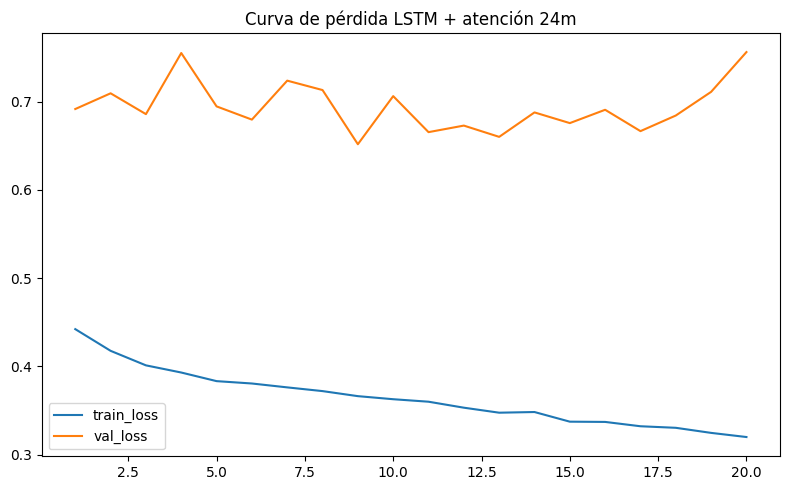

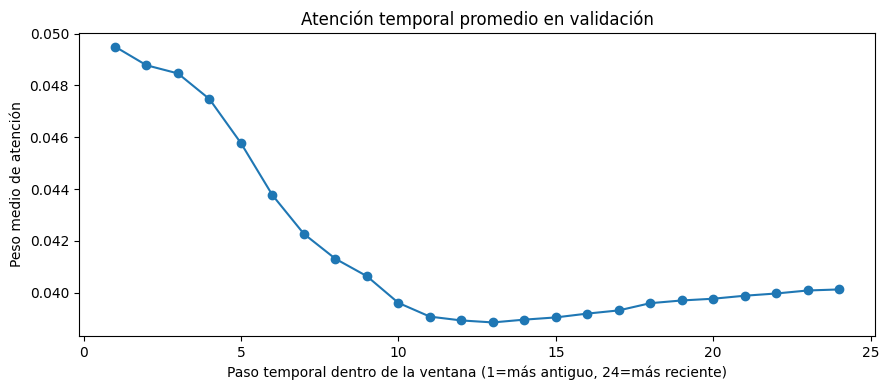


Proceso finalizado: modelo_lstm_atencion_24m_estacional


In [29]:
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_atencion_24m_estacional"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 25
LR = 5e-4
PATIENCE = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# ATENCION TEMPORAL
# =========================================================
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.proj = nn.Linear(hidden_size, hidden_size)
        self.score = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, h_seq):
        # h_seq: [B, T, H]
        e = torch.tanh(self.proj(h_seq))          # [B, T, H]
        scores = self.score(e).squeeze(-1)        # [B, T]
        alpha = torch.softmax(scores, dim=1)      # [B, T]
        context = torch.sum(h_seq * alpha.unsqueeze(-1), dim=1)  # [B, H]
        return context, alpha

# =========================================================
# MODELO LSTM + ATENCION
# =========================================================
class ModeloLSTMAttention(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.attn = TemporalAttention(hidden_size)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x, return_attention=False):
        h_seq, _ = self.lstm(x)                   # [B, T, H]
        context, alpha = self.attn(h_seq)        # [B, H], [B, T]
        logits = self.fc(context).squeeze(1)     # [B]

        if return_attention:
            return logits, alpha
        return logits

model = ModeloLSTMAttention(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5, collect_attention=False):
    model.eval()
    losses = []
    y_true, y_prob = [], []
    attentions = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            if collect_attention:
                logits, alpha = model(xb, return_attention=True)
                attentions.append(alpha.cpu().numpy())
            else:
                logits = model(xb)

            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    salida = {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

    if collect_attention and attentions:
        salida["attention_mean"] = np.concatenate(attentions, axis=0).mean(axis=0)

    return salida

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(model.state_dict(), os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_attention.pt"))
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(torch.load(os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_attention.pt"), map_location=DEVICE))

val_final_raw = evaluar(val_dl, threshold=0.5, collect_attention=True)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo, collect_attention=True)
test_final = evaluar(test_dl, threshold=umbral_optimo, collect_attention=False)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion", "attention_mean"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR HISTORIAL Y GRAFICOS
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(os.path.join(CARPETA_SALIDA, "historial_lstm_attention.csv"), index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM + atención 24m")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_attention.png"), dpi=200)
plt.show()

# Atención promedio en validación
if "attention_mean" in val_final:
    att = val_final["attention_mean"]
    pasos = np.arange(1, len(att) + 1)

    plt.figure(figsize=(9, 4))
    plt.plot(pasos, att, marker="o")
    plt.xlabel("Paso temporal dentro de la ventana (1=más antiguo, 24=más reciente)")
    plt.ylabel("Peso medio de atención")
    plt.title("Atención temporal promedio en validación")
    plt.tight_layout()
    plt.savefig(os.path.join(CARPETA_SALIDA, "atencion_promedio_validacion.png"), dpi=200)
    plt.show()

# =========================================================
# GUARDAR METADATOS
# =========================================================
meta = {
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {k: v for k, v in val_final.items() if k not in ["y_true", "y_prob", "y_pred", "attention_mean"]},
    "metricas_prueba_final": {k: v for k, v in test_final.items() if k not in ["y_true", "y_prob", "y_pred"]},
}

if "attention_mean" in val_final:
    meta["attention_mean_validacion"] = val_final["attention_mean"].tolist()

with open(os.path.join(CARPETA_SALIDA, "metadatos_lstm_attention.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Apreciaciones del modelo 5, este se acercó al mejor que es el modelo 3 de estacionalidad 24m, sin embargo, queda corto con en precision y AUC. Esto significa que si se prioriza el balance general y ranking de riesgo se gana el LSTM 24m, pero si se prioriza la sensibilidad/recall, el LSTM + atención tiene mejor performance.

### Resultado 5

- BATCH_SIZE = 64
- EPOCHS = 25
- LR = 5e-4
- PATIENCE = 5

PRUEBA FINAL
- loss : 0.4757285958058885
- roc_auc : 0.8672539213108783
- pr_auc : 0.07149196178981532
- brier : 0.02373363822698593
- precision : 0.0774818401937046
- recall : 0.4383561643835616
- f1 : 0.13168724279835392

### Modelo 6

Por lo que se observa, los modelos variados no están mejorando el performance del modelo, por lo que se considera cambiar el Batch_size, lr patiente para ver is mejor con el mejor modelo que es el 3 LSTM 24m.

Comenzamos con: 
- batch_size = 32
- lr = 5e-4
- patience = 6

Esto con el fin de ver si mejora la generalizacion y recall.

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.6621 | val_loss=1.1947 | val_roc_auc=0.7860 | val_pr_auc=0.0264 | val_f1=0.0000
Epoch 2 | train_loss=0.6106 | val_loss=1.0651 | val_roc_auc=0.7928 | val_pr_auc=0.0238 | val_f1=0.0000
Epoch 3 | train_loss=0.6020 | val_loss=0.9959 | val_roc_auc=0.8135 | val_pr_auc=0.0273 | val_f1=0.0000
Epoch 4 | train_loss=0.5962 | val_loss=1.0376 | val_roc_auc=0.8144 | val_pr_auc=0.0267 | val_f1=0.0000
Epoch 5 | train_loss=0.5726 | val_loss=1.0136 | val_roc_auc=0.8194 | val_pr_auc=0.0285 | val_f1=0.0000
Epoch 6 | train_loss=0.5564 | val_loss=0.9335 | val_roc_auc=0.8232 | val_pr_auc=0.0284 | val_f1=0.0000
Epoch 7 | train_loss=0.5521 | val_loss=1.0415 | val_roc_auc=0.8234 | val_pr_auc=0.0296 | val_f1=0.0000
Epoch 8 | train_loss=0.5480 | val_loss=0.9886 | val_roc_auc=0.8267 | val_pr_auc=0.0279 | val_f1=0.0000
Epoch 9 | train_loss=0.5439 | val_loss=1.1

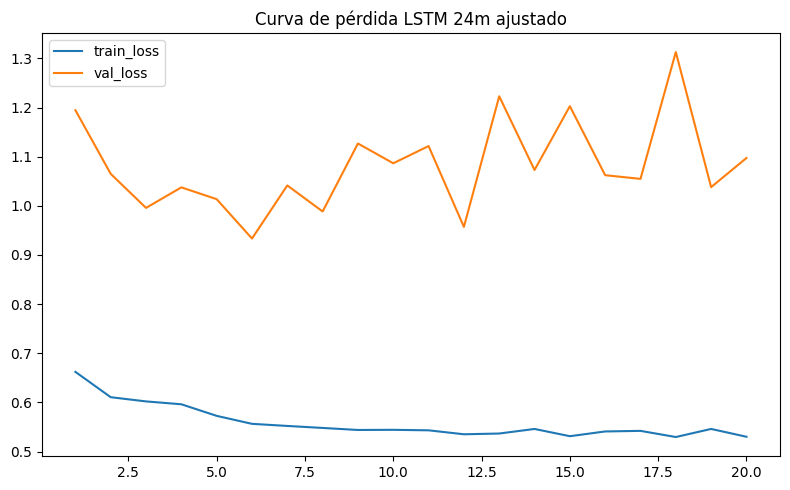

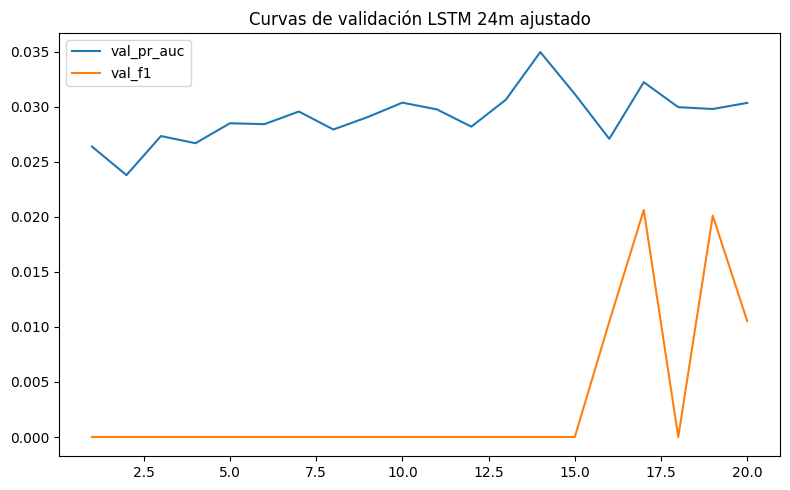


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [31]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 32
EPOCHS = 30
LR = 5e-4
PATIENCE = 6
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Consideración del modelo 6, los ajuste que se realizaron si cambio el modelo, pero no fue le mejor, este mejoro en ROC-AUC:0.9135, precision: 0.0982 y F1: 0.1481, pero empeoró en PR-AUC y recall. Este hizo un modelo más selectivo donde dispara menos alertas, acierta mejor cuando alerta y no deja pasar eventos reales. Con lo anterior sigue siendo mejor el modelo base 24m.

### Resultado 6

- BATCH_SIZE = 32
- EPOCHS = 30
- LR = 5e-4
- PATIENCE = 6

PRUEBA FINAL
- loss : 0.7525657713015048
- roc_auc : 0.9135188937980221
- pr_auc : 0.08169933615547373
- brier : 0.005744919180870056
- precision : 0.09821428571428571
- recall : 0.3013698630136986
- f1 : 0.14814814814814814

### Modelo 7

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.5248 | val_loss=0.9363 | val_roc_auc=0.7714 | val_pr_auc=0.0294 | val_f1=0.0000
Epoch 2 | train_loss=0.4888 | val_loss=0.8271 | val_roc_auc=0.7822 | val_pr_auc=0.0307 | val_f1=0.0290
Epoch 3 | train_loss=0.4829 | val_loss=0.7823 | val_roc_auc=0.8032 | val_pr_auc=0.0298 | val_f1=0.0458
Epoch 4 | train_loss=0.4881 | val_loss=0.8723 | val_roc_auc=0.8066 | val_pr_auc=0.0307 | val_f1=0.0534
Epoch 5 | train_loss=0.4701 | val_loss=0.8795 | val_roc_auc=0.8097 | val_pr_auc=0.0300 | val_f1=0.0436
Epoch 6 | train_loss=0.4658 | val_loss=0.7889 | val_roc_auc=0.8158 | val_pr_auc=0.0291 | val_f1=0.0469
Epoch 7 | train_loss=0.4644 | val_loss=0.8191 | val_roc_auc=0.8134 | val_pr_auc=0.0294 | val_f1=0.0502
Epoch 8 | train_loss=0.4676 | val_loss=0.7997 | val_roc_auc=0.8242 | val_pr_auc=0.0293 | val_f1=0.0316
Epoch 9 | train_loss=0.4565 | val_loss=0.8

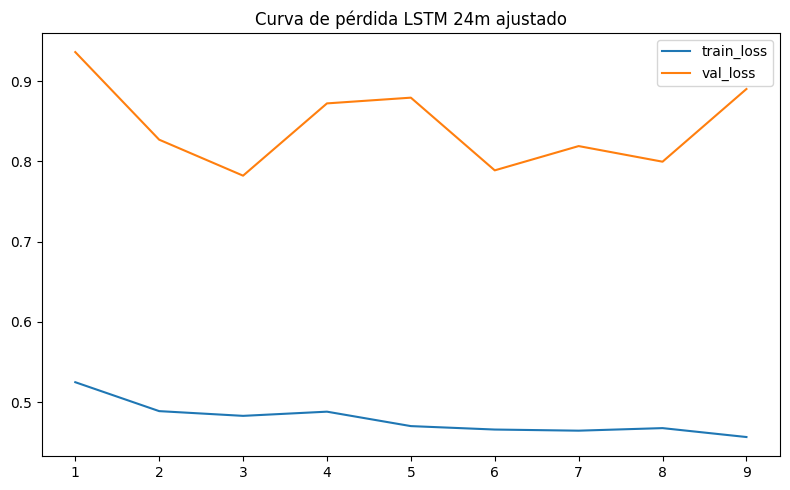

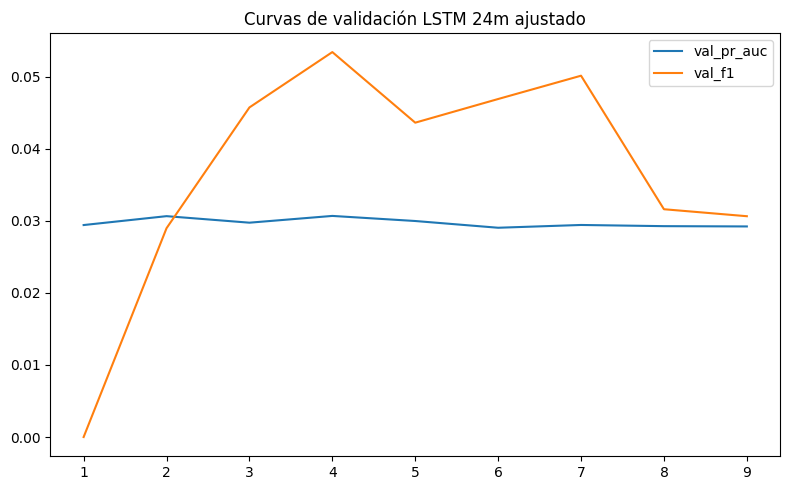


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [32]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 64
EPOCHS = 30
LR = 5e-4
PATIENCE = 5
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 7

- BATCH_SIZE = 64
- EPOCHS = 30
- LR = 5e-4
- PATIENCE = 5

PRUEBA FINAL
- loss : 0.5628102626342556
- roc_auc : 0.8981916908003024
- pr_auc : 0.08912079458452205
- brier : 0.009232457727193832
- precision : 0.09237875288683603
- recall : 0.547945205479452
- f1 : 0.15810276679841898

### Modelo 8

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.4969 | val_loss=0.8166 | val_roc_auc=0.7580 | val_pr_auc=0.0200 | val_f1=0.0000
Epoch 2 | train_loss=0.4474 | val_loss=0.7585 | val_roc_auc=0.7772 | val_pr_auc=0.0246 | val_f1=0.0279
Epoch 3 | train_loss=0.4362 | val_loss=0.7364 | val_roc_auc=0.7910 | val_pr_auc=0.0256 | val_f1=0.0462
Epoch 4 | train_loss=0.4438 | val_loss=0.8475 | val_roc_auc=0.7924 | val_pr_auc=0.0272 | val_f1=0.0481
Epoch 5 | train_loss=0.4409 | val_loss=0.8336 | val_roc_auc=0.8036 | val_pr_auc=0.0273 | val_f1=0.0351
Epoch 6 | train_loss=0.4334 | val_loss=0.7372 | val_roc_auc=0.8113 | val_pr_auc=0.0264 | val_f1=0.0480
Epoch 7 | train_loss=0.4353 | val_loss=0.7647 | val_roc_auc=0.8079 | val_pr_auc=0.0261 | val_f1=0.0196
Epoch 8 | train_loss=0.4356 | val_loss=0.7829 | val_roc_auc=0.8135 | val_pr_auc=0.0270 | val_f1=0.0163
Epoch 9 | train_loss=0.4244 | val_loss=0.8

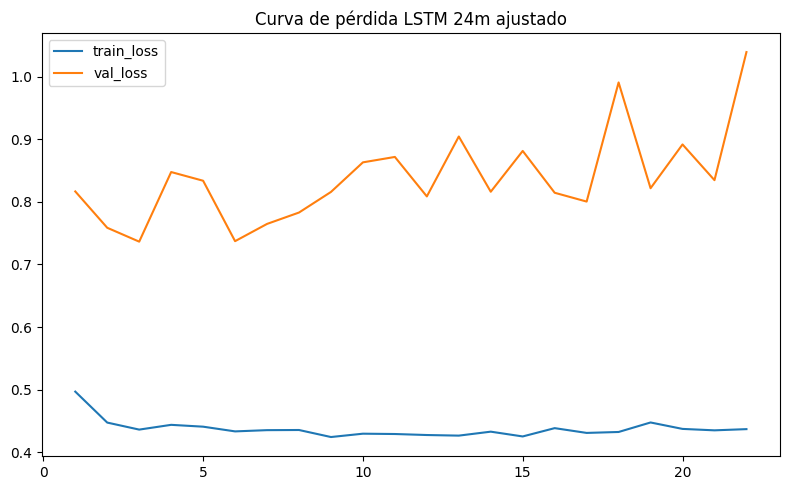

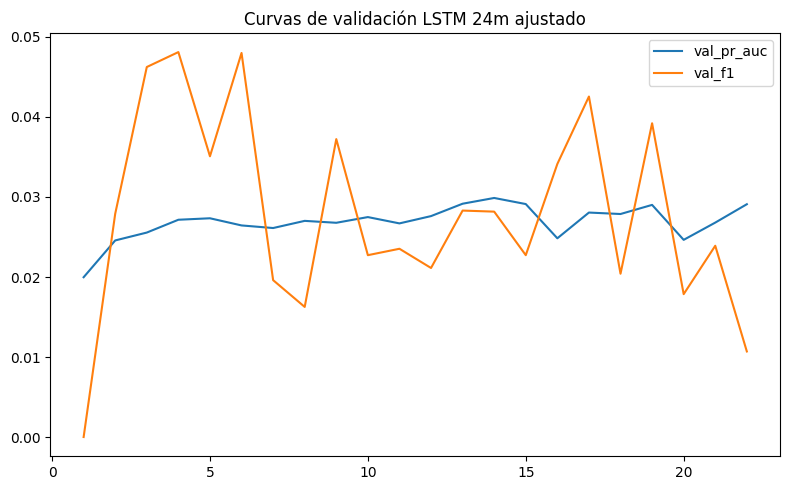


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [33]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 100
EPOCHS = 30
LR = 3e-4
PATIENCE = 8
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 8

- BATCH_SIZE = 100
- EPOCHS = 30
- LR = 3e-4
- PATIENCE = 8

PRUEBA FINAL
- loss : 0.5448201055466025
- roc_auc : 0.9089983765420038
- pr_auc : 0.08173505918691142
- brier : 0.009864055551588535
- precision : 0.0807799442896936
- recall : 0.3972602739726027
- f1 : 0.13425925925925927

### Modelo 9

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
Epoch 1 | train_loss=0.0048 | val_loss=0.0061 | val_roc_auc=0.7957 | val_pr_auc=0.0259 | val_f1=0.0000
Epoch 2 | train_loss=0.0037 | val_loss=0.0060 | val_roc_auc=0.8007 | val_pr_auc=0.0255 | val_f1=0.0000
Epoch 3 | train_loss=0.0036 | val_loss=0.0059 | val_roc_auc=0.8205 | val_pr_auc=0.0316 | val_f1=0.0000
Epoch 4 | train_loss=0.0036 | val_loss=0.0057 | val_roc_auc=0.8302 | val_pr_auc=0.0330 | val_f1=0.0000
Epoch 5 | train_loss=0.0035 | val_loss=0.0057 | val_roc_auc=0.8379 | val_pr_auc=0.0345 | val_f1=0.0000
Epoch 6 | train_loss=0.0035 | val_loss=0.0056 | val_roc_auc=0.8432 | val_pr_auc=0.0351 | val_f1=0.0000
Epoch 7 | train_loss=0.0035 | val_loss=0.0060 | val_roc_auc=0.8370 | val_pr_auc=0.0341 | val_f1=0.0000
Epoch 8 | train_loss=0.0034 | val_loss=0.0058 | val_roc_auc=0.8343 | val_pr_auc=0.0296 | val_f1=0.0000
Epoch 9 | train_loss=0.0034 | val_loss=0.0060 | val_roc_auc

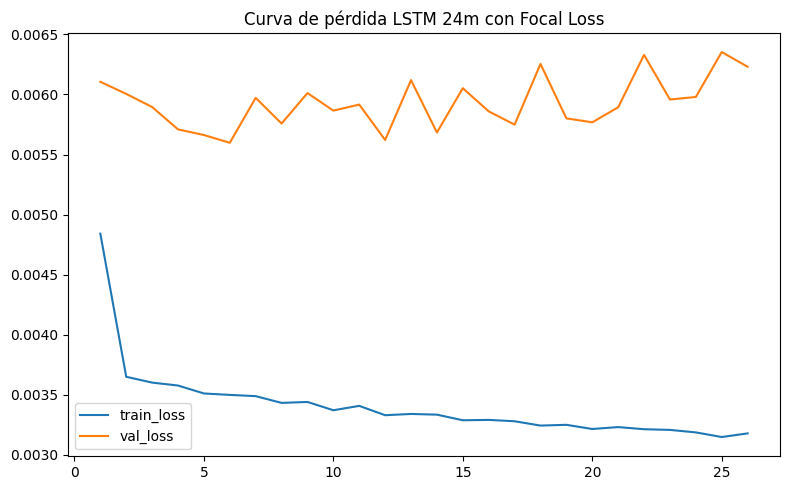

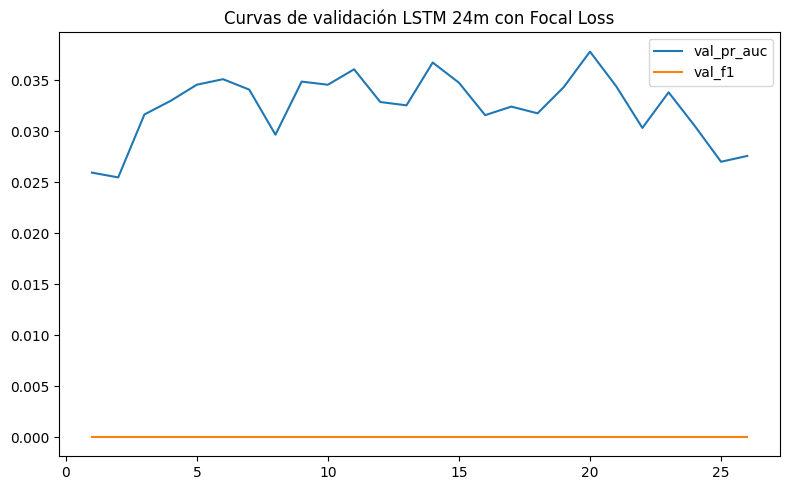


Proceso finalizado: modelo_lstm_24m_estacional_focal


In [35]:
import random
import torch.nn.functional as F
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_focal"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 32
EPOCHS = 30
LR = 5e-4
PATIENCE = 6
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

# Parámetros focal loss
FOCAL_ALPHA = 0.75
FOCAL_GAMMA = 2.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

# =========================================================
# FOCAL LOSS BINARIA
# =========================================================
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()

        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)

        alpha_t = torch.where(
            targets == 1,
            torch.full_like(targets, self.alpha),
            torch.full_like(targets, 1 - self.alpha)
        )

        focal = alpha_t * ((1 - pt) ** self.gamma) * bce

        if self.reduction == "mean":
            return focal.mean()
        elif self.reduction == "sum":
            return focal.sum()
        return focal

criterion = BinaryFocalLoss(
    alpha=FOCAL_ALPHA,
    gamma=FOCAL_GAMMA,
    reduction="mean"
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_focal.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_focal.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_focal.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m con Focal Loss")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_focal.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m con Focal Loss")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_focal.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "focal_alpha": FOCAL_ALPHA,
    "focal_gamma": FOCAL_GAMMA,
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_focal.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

De los últimos tres modelos, el mejor el el 7 con unBATCH 64, lr 5e-4, patience 5 con ROC-AUC = 0.8982, PR-AUC = 0.0891, Precision = 0.0924, Recall = 0.5479 y F1 = 0.1581 en prueba;
El ajustado 1 gana de forma bastante clara porque logra el mejor equilibrio entre detección y calidad de alerta: tiene el mejor F1: 0.1581 tiene el mayor recall: 0.5479 mantiene una precision aceptable: 0.0924 su PR-AUC = 0.0891 queda apenas un poco por debajo del Focal (0.0909), pero la diferencia es muy pequeña

En términos prácticos, el Focal: rankea un poco mejor, pero detecta menos eventos.

El ajustado 1:detecta muchos más positivos, y en conjunto clasifica mejor.
Objetivo general
Desarrollar un modelo híbrido de precios de reaseguro que integre predicción de daños basada en aprendizaje automático con mecanismos de transferencia de riesgo.
2.2. Objetivos especificos
1. OE1: Construir un modelo geoespacial (Random Forest + U-Net) para predecir pérdidas.
2. OE2: Diseñar un sistema de alerta temprana con LSTM para acumulación de pérdidas
5
Pontificia Universidad Javeriana 3 Marco teórico
por inundaciones.
3. OE3: Desarrollar una estructura eficiente de reaseguro con triggers generados por ML.

### Resultado 9

BATCH_SIZE = 32
EPOCHS = 30
LR = 5e-4
PATIENCE = 6

PRUEBA FINAL
loss : 0.004311916069093054
roc_auc : 0.9113123412473927
pr_auc : 0.09091129360552239
brier : 0.021992532536387444
precision : 0.08839779005524862
recall : 0.2191780821917808
f1 : 0.12598425196850394

### Modelo 10

Pruebo sobre el mejor modelo ajustado.

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.5091 | val_loss=0.8807 | val_roc_auc=0.7688 | val_pr_auc=0.0224 | val_f1=0.0000
Epoch 2 | train_loss=0.4641 | val_loss=0.8147 | val_roc_auc=0.7778 | val_pr_auc=0.0287 | val_f1=0.0198
Epoch 3 | train_loss=0.4595 | val_loss=0.7732 | val_roc_auc=0.7938 | val_pr_auc=0.0257 | val_f1=0.0426
Epoch 4 | train_loss=0.4624 | val_loss=0.8899 | val_roc_auc=0.7948 | val_pr_auc=0.0259 | val_f1=0.0239
Epoch 5 | train_loss=0.4546 | val_loss=0.8741 | val_roc_auc=0.8041 | val_pr_auc=0.0277 | val_f1=0.0383
Epoch 6 | train_loss=0.4475 | val_loss=0.7738 | val_roc_auc=0.8105 | val_pr_auc=0.0271 | val_f1=0.0539
Epoch 7 | train_loss=0.4478 | val_loss=0.7892 | val_roc_auc=0.8067 | val_pr_auc=0.0272 | val_f1=0.0427
Early stopping

MEJOR EPOCH: 2
MEJOR VAL PR-AUC: 0.028688051369817356
UMBRAL OPTIMO: 0.39000000000000007

VALIDACION FINAL
loss : 0.8146662607053

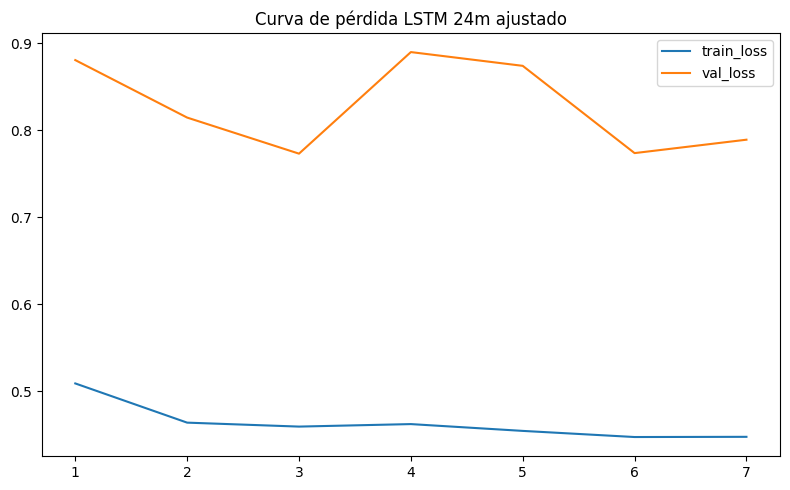

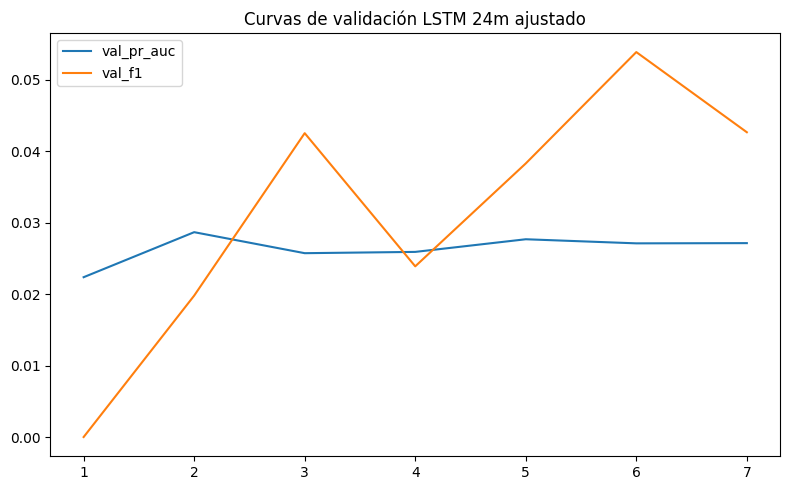


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [36]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 80
EPOCHS = 30
LR = 4e-4
PATIENCE = 5
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

- BATCH_SIZE = 80
- EPOCHS = 30
- LR = 4e-4
- PATIENCE = 5

PRUEBA FINAL
- loss : 0.56159309662614
- roc_auc : 0.8749129194316771
- pr_auc : 0.06662626983788558
- brier : 0.010690308175981045
- precision : 0.11842105263157894
- recall : 0.2465753424657534
- f1 : 0.16

### Resultado 11

- BATCH_SIZE = 80
- EPOCHS = 30
- LR = 4e-4
- PATIENCE = 5
- WEIGHT_DECAY = 1e-5
- GRAD_CLIP = 1.0


PRUEBA FINAL
- loss : 0.56159309662614
- roc_auc : 0.8749129194316771
- pr_auc : 0.06662626983788558
- brier : 0.010690308175981045
- precision : 0.11842105263157894
- recall : 0.2465753424657534
- f1 : 0.16

### Modelo 12

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.5125 | val_loss=0.9028 | val_roc_auc=0.7624 | val_pr_auc=0.0208 | val_f1=0.0000
Epoch 2 | train_loss=0.4760 | val_loss=0.8391 | val_roc_auc=0.7788 | val_pr_auc=0.0288 | val_f1=0.0115
Epoch 3 | train_loss=0.4697 | val_loss=0.8068 | val_roc_auc=0.7910 | val_pr_auc=0.0249 | val_f1=0.0241
Epoch 4 | train_loss=0.4721 | val_loss=0.9316 | val_roc_auc=0.7889 | val_pr_auc=0.0249 | val_f1=0.0185
Epoch 5 | train_loss=0.4707 | val_loss=0.9135 | val_roc_auc=0.8020 | val_pr_auc=0.0272 | val_f1=0.0187
Epoch 6 | train_loss=0.4665 | val_loss=0.8082 | val_roc_auc=0.8063 | val_pr_auc=0.0258 | val_f1=0.0166
Epoch 7 | train_loss=0.4624 | val_loss=0.8151 | val_roc_auc=0.8055 | val_pr_auc=0.0261 | val_f1=0.0247
Early stopping

MEJOR EPOCH: 2
MEJOR VAL PR-AUC: 0.028752435262684967
UMBRAL OPTIMO: 0.34

VALIDACION FINAL
loss : 0.8390500763381448
roc_auc : 0

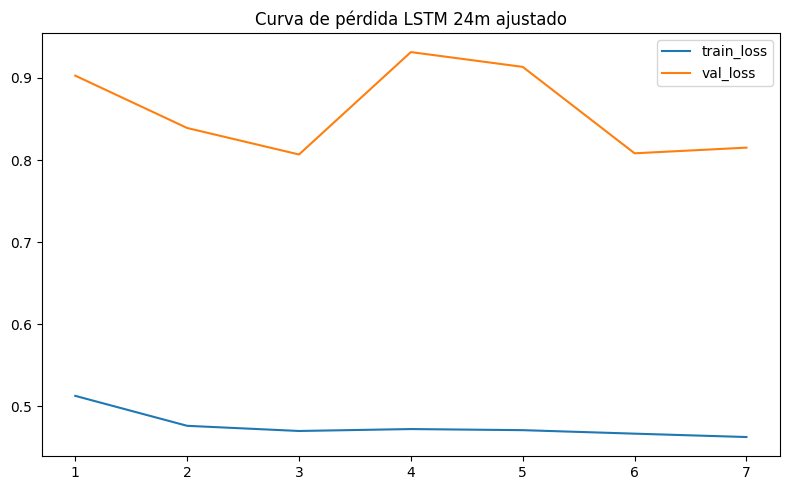

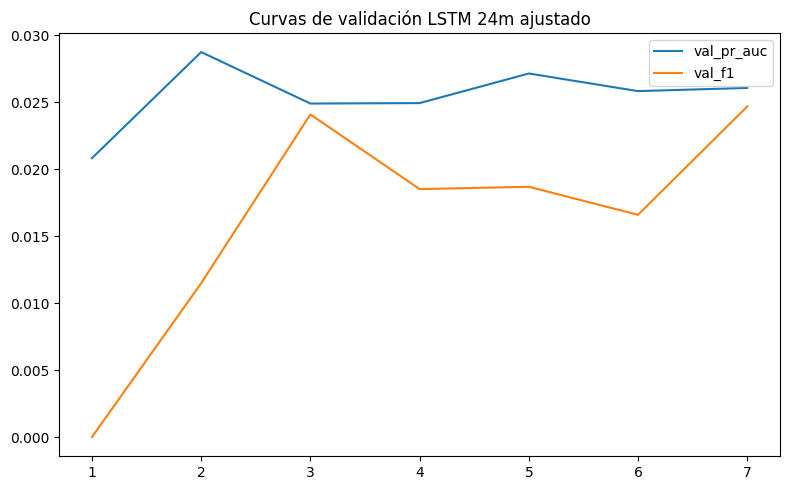


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [37]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 80
EPOCHS = 30
LR = 3e-4
PATIENCE = 5
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 12

- BATCH_SIZE = 80
- EPOCHS = 30
- LR = 3e-4
- PATIENCE = 5
- WEIGHT_DECAY = 1e-5
- GRAD_CLIP = 1.0

PRUEBA FINAL
- loss : 0.5734429467171871
- roc_auc : 0.8827867418619948
- pr_auc : 0.06471727734535122
- brier : 0.009698214009404182
- precision : 0.1
- recall : 0.2602739726027397
- f1 : 0.1444866920152091

### Modelo 13

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.5274 | val_loss=0.9504 | val_roc_auc=0.7665 | val_pr_auc=0.0272 | val_f1=0.0000
Epoch 2 | train_loss=0.4834 | val_loss=0.8590 | val_roc_auc=0.7763 | val_pr_auc=0.0286 | val_f1=0.0110
Epoch 3 | train_loss=0.4787 | val_loss=0.8203 | val_roc_auc=0.7951 | val_pr_auc=0.0271 | val_f1=0.0256
Epoch 4 | train_loss=0.4844 | val_loss=0.8732 | val_roc_auc=0.8000 | val_pr_auc=0.0285 | val_f1=0.0243
Epoch 5 | train_loss=0.4685 | val_loss=0.8813 | val_roc_auc=0.8062 | val_pr_auc=0.0298 | val_f1=0.0343
Epoch 6 | train_loss=0.4620 | val_loss=0.7892 | val_roc_auc=0.8100 | val_pr_auc=0.0272 | val_f1=0.0486
Epoch 7 | train_loss=0.4677 | val_loss=0.8275 | val_roc_auc=0.8119 | val_pr_auc=0.0289 | val_f1=0.0303
Epoch 8 | train_loss=0.4719 | val_loss=0.8334 | val_roc_auc=0.8217 | val_pr_auc=0.0290 | val_f1=0.0091
Epoch 9 | train_loss=0.4556 | val_loss=0.9

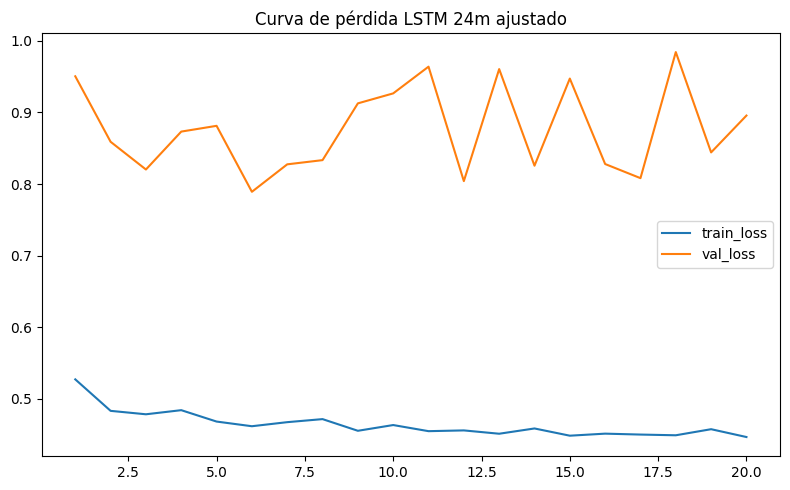

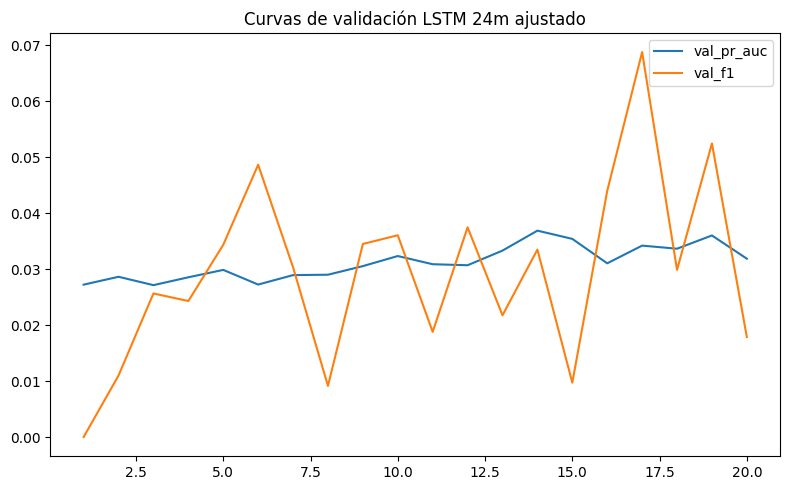


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [38]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 70
EPOCHS = 30
LR = 4e-4
PATIENCE = 6
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 13

- BATCH_SIZE = 70
- EPOCHS = 30
- LR = 4e-4
- PATIENCE = 6
- WEIGHT_DECAY = 1e-5
- GRAD_CLIP = 1.0

PRUEBA FINAL
- loss : 0.5748418628894411
- roc_auc : 0.9154441288004722
- pr_auc : 0.08717070742999676
- brier : 0.007953833788633347
- precision : 0.09642857142857143
- recall : 0.3698630136986301
- f1 : 0.1529745042492918

### Modelo 14

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.5952 | val_loss=1.1281 | val_roc_auc=0.7622 | val_pr_auc=0.0198 | val_f1=0.0000
Epoch 2 | train_loss=0.5744 | val_loss=1.0147 | val_roc_auc=0.7843 | val_pr_auc=0.0237 | val_f1=0.0000
Epoch 3 | train_loss=0.5689 | val_loss=1.0190 | val_roc_auc=0.7936 | val_pr_auc=0.0258 | val_f1=0.0000
Epoch 4 | train_loss=0.5736 | val_loss=1.1087 | val_roc_auc=0.7888 | val_pr_auc=0.0246 | val_f1=0.0000
Epoch 5 | train_loss=0.5636 | val_loss=1.0924 | val_roc_auc=0.7968 | val_pr_auc=0.0257 | val_f1=0.0000
Epoch 6 | train_loss=0.5591 | val_loss=1.0089 | val_roc_auc=0.8023 | val_pr_auc=0.0254 | val_f1=0.0000
Epoch 7 | train_loss=0.5581 | val_loss=1.0400 | val_roc_auc=0.8025 | val_pr_auc=0.0253 | val_f1=0.0000
Epoch 8 | train_loss=0.5647 | val_loss=1.0769 | val_roc_auc=0.8004 | val_pr_auc=0.0250 | val_f1=0.0000
Early stopping

MEJOR EPOCH: 3
MEJOR VAL P

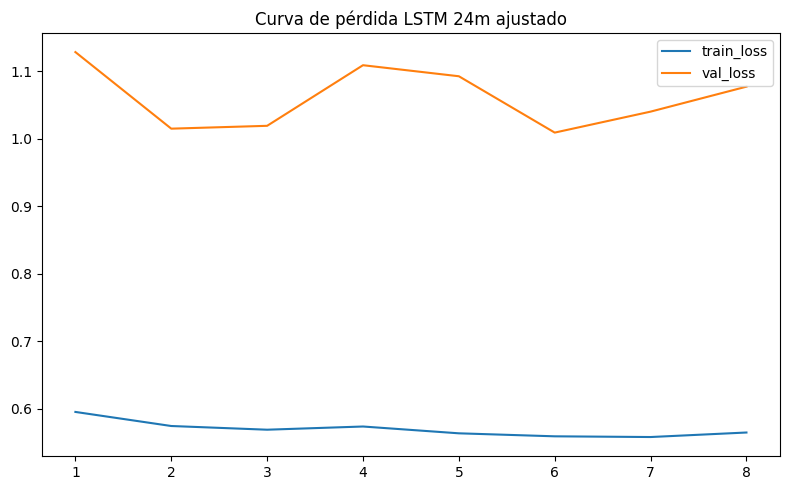

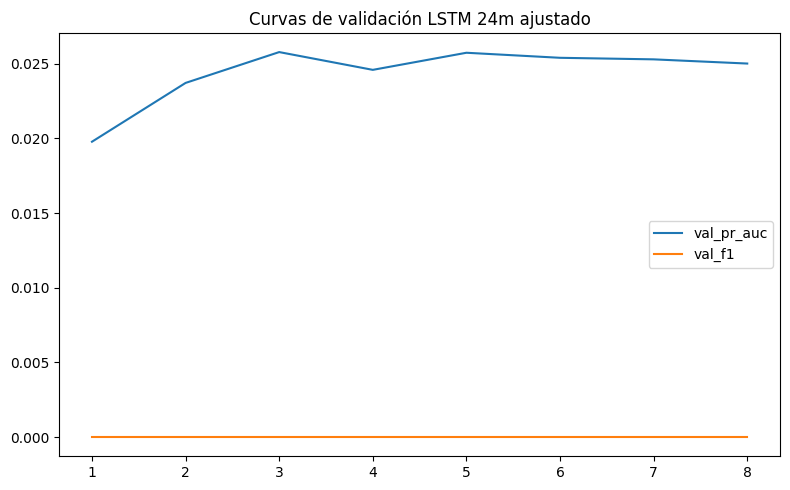


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [39]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 50
EPOCHS = 30
LR = 2e-4
PATIENCE = 5
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 14

- BATCH_SIZE = 50
- EPOCHS = 30
- LR = 2e-4
- PATIENCE = 5
- WEIGHT_DECAY = 1e-5
- GRAD_CLIP = 1.0

PRUEBA FINAL
- loss : 0.7233171754344194
- roc_auc : 0.8804778920211181
- pr_auc : 0.07019754462720042
- brier : 0.0060795387253165245
- precision : 0.07713498622589532
- recall : 0.3835616438356164
- f1 : 0.12844036697247707

### Modelo 15

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.5050 | val_loss=0.8757 | val_roc_auc=0.7595 | val_pr_auc=0.0209 | val_f1=0.0000
Epoch 2 | train_loss=0.4594 | val_loss=0.7846 | val_roc_auc=0.7766 | val_pr_auc=0.0259 | val_f1=0.0104
Epoch 3 | train_loss=0.4504 | val_loss=0.7620 | val_roc_auc=0.7906 | val_pr_auc=0.0251 | val_f1=0.0395
Epoch 4 | train_loss=0.4611 | val_loss=0.8653 | val_roc_auc=0.7907 | val_pr_auc=0.0270 | val_f1=0.0338
Epoch 5 | train_loss=0.4523 | val_loss=0.8516 | val_roc_auc=0.7999 | val_pr_auc=0.0281 | val_f1=0.0403
Epoch 6 | train_loss=0.4473 | val_loss=0.7705 | val_roc_auc=0.8081 | val_pr_auc=0.0273 | val_f1=0.0449
Epoch 7 | train_loss=0.4466 | val_loss=0.7806 | val_roc_auc=0.8058 | val_pr_auc=0.0272 | val_f1=0.0268
Epoch 8 | train_loss=0.4508 | val_loss=0.8135 | val_roc_auc=0.8095 | val_pr_auc=0.0266 | val_f1=0.0175
Epoch 9 | train_loss=0.4398 | val_loss=0.8

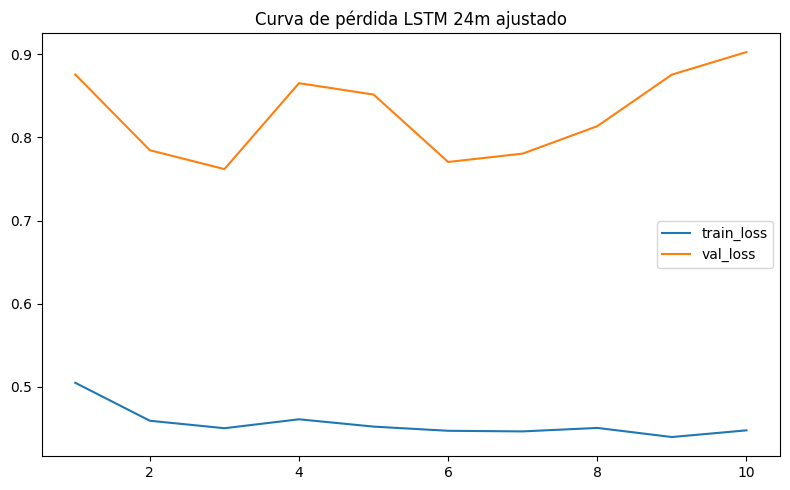

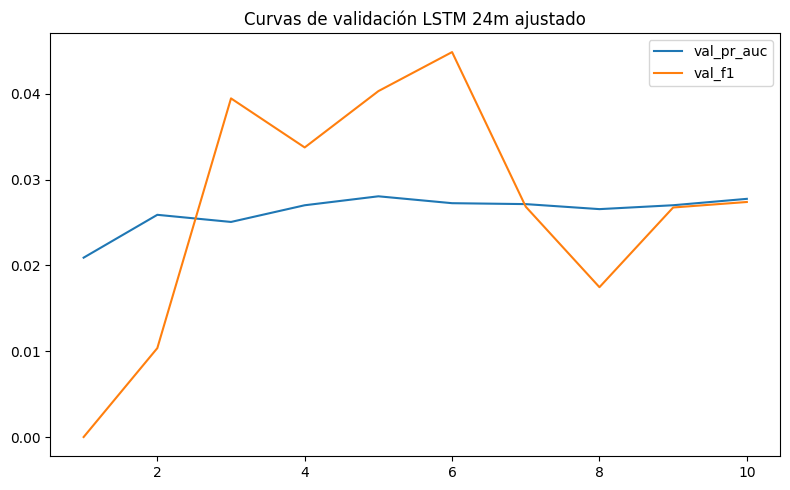


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [40]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 90
EPOCHS = 30
LR = 3e-4
PATIENCE = 5
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 15

- BATCH_SIZE = 90
- EPOCHS = 30
- LR = 3e-4
- PATIENCE = 5

PRUEBA FINAL
- loss : 0.571300447670122
- roc_auc : 0.8897654630026505
- pr_auc : 0.07329290472002055
- brier : 0.009791512042284012
- precision : 0.08430232558139535
- recall : 0.3972602739726027
- f1 : 0.13908872901678657

### Modelo 16

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.4988 | val_loss=0.8716 | val_roc_auc=0.7686 | val_pr_auc=0.0217 | val_f1=0.0000
Epoch 2 | train_loss=0.4493 | val_loss=0.7707 | val_roc_auc=0.7804 | val_pr_auc=0.0245 | val_f1=0.0398
Epoch 3 | train_loss=0.4456 | val_loss=0.7555 | val_roc_auc=0.7963 | val_pr_auc=0.0254 | val_f1=0.0437
Epoch 4 | train_loss=0.4581 | val_loss=0.8280 | val_roc_auc=0.7937 | val_pr_auc=0.0246 | val_f1=0.0479
Epoch 5 | train_loss=0.4397 | val_loss=0.8342 | val_roc_auc=0.8008 | val_pr_auc=0.0258 | val_f1=0.0280
Epoch 6 | train_loss=0.4354 | val_loss=0.7371 | val_roc_auc=0.8081 | val_pr_auc=0.0254 | val_f1=0.0463
Epoch 7 | train_loss=0.4352 | val_loss=0.7643 | val_roc_auc=0.8066 | val_pr_auc=0.0256 | val_f1=0.0423
Epoch 8 | train_loss=0.4413 | val_loss=0.7843 | val_roc_auc=0.8117 | val_pr_auc=0.0261 | val_f1=0.0150
Epoch 9 | train_loss=0.4263 | val_loss=0.8

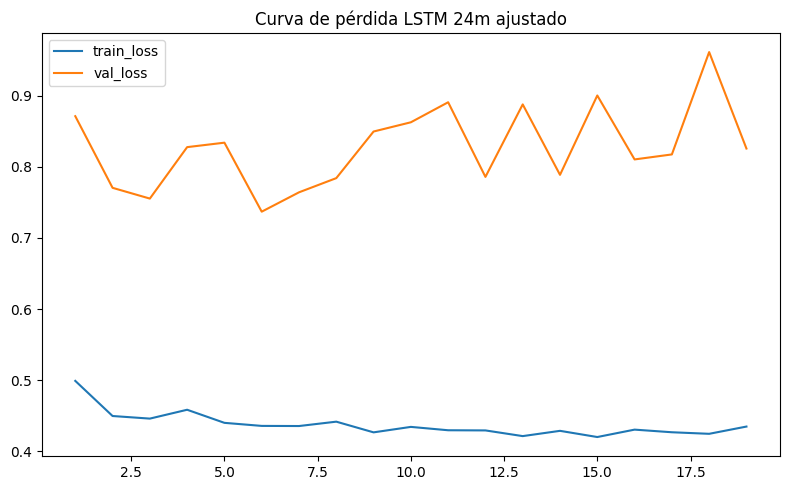

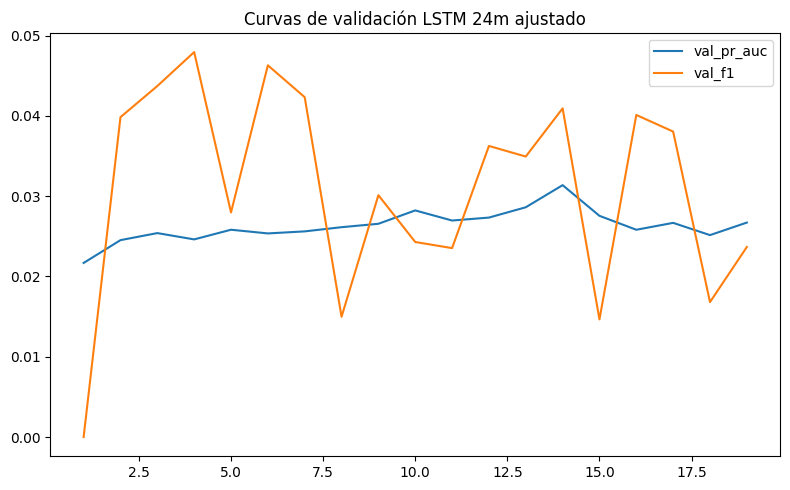


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [41]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 90
EPOCHS = 30
LR = 4e-4
PATIENCE = 5
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 16

- BATCH_SIZE = 90
- EPOCHS = 30
- LR = 4e-4
- PATIENCE = 5

PRUEBA FINAL
- loss : 0.5223358611855656
- roc_auc : 0.9126237925083602
- pr_auc : 0.08017840647285124
- brier : 0.01065885927528143
- precision : 0.1218274111675127
- recall : 0.3287671232876712
- f1 : 0.17777777777777778

### Modelo 17

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.5028 | val_loss=0.8705 | val_roc_auc=0.7697 | val_pr_auc=0.0233 | val_f1=0.0000
Epoch 2 | train_loss=0.4589 | val_loss=0.7929 | val_roc_auc=0.7785 | val_pr_auc=0.0236 | val_f1=0.0175
Epoch 3 | train_loss=0.4539 | val_loss=0.7567 | val_roc_auc=0.7997 | val_pr_auc=0.0262 | val_f1=0.0464
Epoch 4 | train_loss=0.4568 | val_loss=0.8559 | val_roc_auc=0.8064 | val_pr_auc=0.0274 | val_f1=0.0641
Epoch 5 | train_loss=0.4480 | val_loss=0.8499 | val_roc_auc=0.8140 | val_pr_auc=0.0292 | val_f1=0.0523
Epoch 6 | train_loss=0.4438 | val_loss=0.7511 | val_roc_auc=0.8159 | val_pr_auc=0.0290 | val_f1=0.0575
Epoch 7 | train_loss=0.4442 | val_loss=0.7747 | val_roc_auc=0.8187 | val_pr_auc=0.0301 | val_f1=0.0475
Epoch 8 | train_loss=0.4491 | val_loss=0.8014 | val_roc_auc=0.8271 | val_pr_auc=0.0289 | val_f1=0.0082
Epoch 9 | train_loss=0.4353 | val_loss=0.8

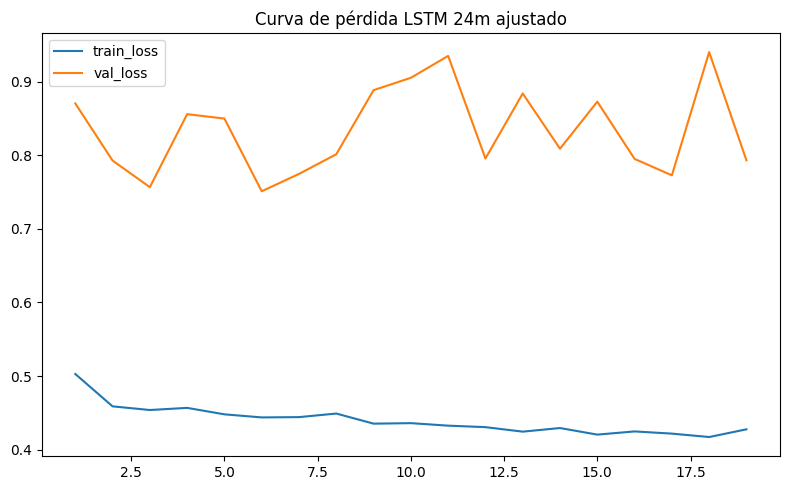

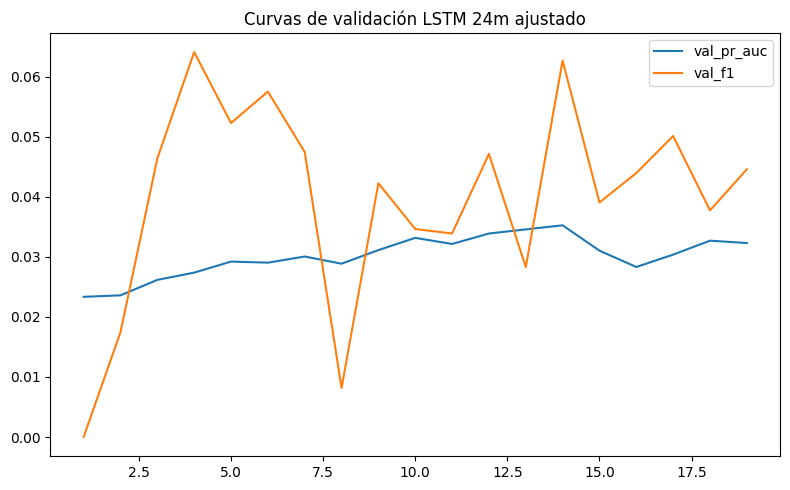


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [42]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 80
EPOCHS = 30
LR = 5e-4
PATIENCE = 5
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 17

- BATCH_SIZE = 80
- EPOCHS = 30
- LR = 5e-4
- PATIENCE = 5

PRUEBA FINAL
- loss : 0.5316805148596419
- roc_auc : 0.9213712337973881
- pr_auc : 0.08106633918707992
- brier : 0.009910877794027328
- precision : 0.09900990099009901
- recall : 0.273972602739726
- f1 : 0.14545454545454545

### Modelo 18

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.5292 | val_loss=0.9087 | val_roc_auc=0.7545 | val_pr_auc=0.0172 | val_f1=0.0000
Epoch 2 | train_loss=0.4926 | val_loss=0.8771 | val_roc_auc=0.7733 | val_pr_auc=0.0236 | val_f1=0.0000
Epoch 3 | train_loss=0.4855 | val_loss=0.8459 | val_roc_auc=0.7847 | val_pr_auc=0.0247 | val_f1=0.0116
Epoch 4 | train_loss=0.4883 | val_loss=0.9403 | val_roc_auc=0.7836 | val_pr_auc=0.0237 | val_f1=0.0106
Epoch 5 | train_loss=0.4833 | val_loss=0.9435 | val_roc_auc=0.7963 | val_pr_auc=0.0253 | val_f1=0.0104
Epoch 6 | train_loss=0.4881 | val_loss=0.8614 | val_roc_auc=0.8022 | val_pr_auc=0.0246 | val_f1=0.0099
Epoch 7 | train_loss=0.4851 | val_loss=0.8567 | val_roc_auc=0.8040 | val_pr_auc=0.0248 | val_f1=0.0101
Epoch 8 | train_loss=0.4916 | val_loss=0.9231 | val_roc_auc=0.8031 | val_pr_auc=0.0251 | val_f1=0.0112
Epoch 9 | train_loss=0.4794 | val_loss=0.9

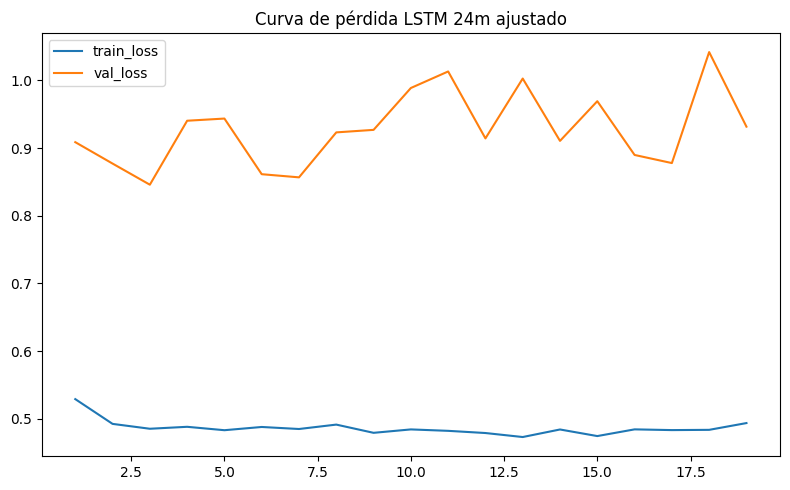

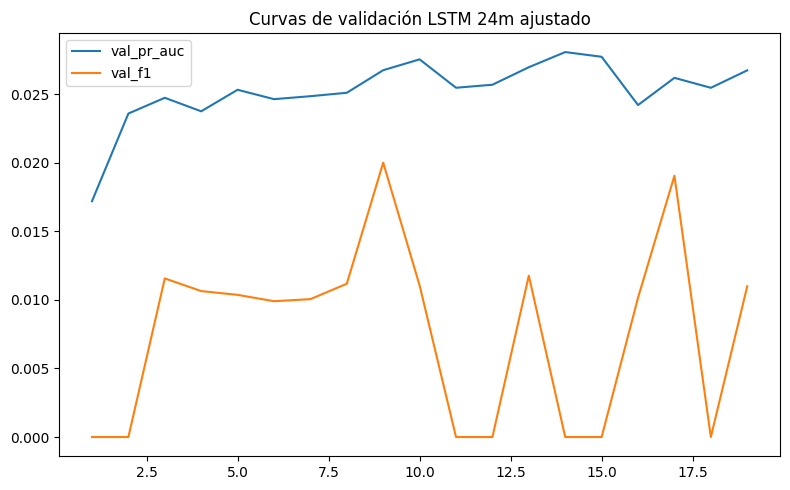


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [43]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 80
EPOCHS = 30
LR = 2e-4
PATIENCE = 5
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 18

- BATCH_SIZE = 80
- EPOCHS = 30
- LR = 2e-4
- PATIENCE = 5

PRUEBA FINAL

- loss : 0.607486085351777
- roc_auc : 0.9118115520237985
- pr_auc : 0.08707882028982407
- brier : 0.007334556896239519
- precision : 0.09243697478991597
- recall : 0.4520547945205479
- f1 : 0.15348837209302327

### Modelo 19

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.4772 | val_loss=0.7368 | val_roc_auc=0.7586 | val_pr_auc=0.0195 | val_f1=0.0000
Epoch 2 | train_loss=0.4154 | val_loss=0.6833 | val_roc_auc=0.7774 | val_pr_auc=0.0230 | val_f1=0.0593
Epoch 3 | train_loss=0.4027 | val_loss=0.6772 | val_roc_auc=0.7963 | val_pr_auc=0.0256 | val_f1=0.0607
Epoch 4 | train_loss=0.4073 | val_loss=0.7483 | val_roc_auc=0.7989 | val_pr_auc=0.0303 | val_f1=0.0568
Epoch 5 | train_loss=0.4009 | val_loss=0.7411 | val_roc_auc=0.8056 | val_pr_auc=0.0288 | val_f1=0.0626
Epoch 6 | train_loss=0.3921 | val_loss=0.6433 | val_roc_auc=0.8108 | val_pr_auc=0.0290 | val_f1=0.0656
Epoch 7 | train_loss=0.3940 | val_loss=0.6870 | val_roc_auc=0.8061 | val_pr_auc=0.0283 | val_f1=0.0632
Epoch 8 | train_loss=0.3950 | val_loss=0.6921 | val_roc_auc=0.8110 | val_pr_auc=0.0290 | val_f1=0.0643
Epoch 9 | train_loss=0.3872 | val_loss=0.7

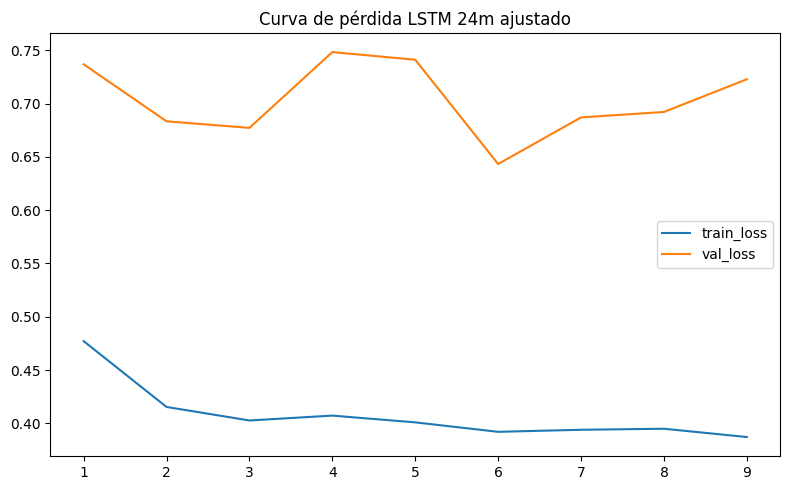

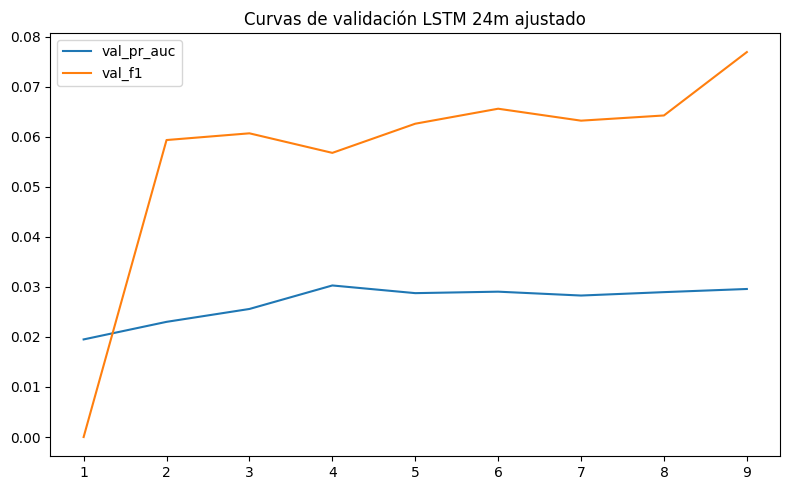


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [44]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 128
EPOCHS = 30
LR = 4e-4
PATIENCE = 5
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 19

- BATCH_SIZE = 128
- EPOCHS = 30
- LR = 4e-4
- PATIENCE = 5

PRUEBA FINAL
- loss : 0.4847157161050248
- roc_auc : 0.8911004426403748
- pr_auc : 0.07696367307318708
- brier : 0.01717648282647133
- precision : 0.078125
- recall : 0.4794520547945205
- f1 : 0.1343570057581574

### Modelo 20

DEVICE: cpu
Train: (133518, 24, 20) 0.0032579878
Val: (26928, 24, 20) 0.006201723
Test: (13464, 24, 20) 0.0054218657
pos_weight: 50.0
Epoch 1 | train_loss=0.4874 | val_loss=0.8066 | val_roc_auc=0.7647 | val_pr_auc=0.0269 | val_f1=0.0119
Epoch 2 | train_loss=0.4364 | val_loss=0.7306 | val_roc_auc=0.7801 | val_pr_auc=0.0233 | val_f1=0.0478
Epoch 3 | train_loss=0.4273 | val_loss=0.7192 | val_roc_auc=0.7925 | val_pr_auc=0.0263 | val_f1=0.0558
Epoch 4 | train_loss=0.4349 | val_loss=0.8043 | val_roc_auc=0.7973 | val_pr_auc=0.0283 | val_f1=0.0573
Epoch 5 | train_loss=0.4239 | val_loss=0.8041 | val_roc_auc=0.8041 | val_pr_auc=0.0282 | val_f1=0.0490
Epoch 6 | train_loss=0.4175 | val_loss=0.7162 | val_roc_auc=0.8076 | val_pr_auc=0.0270 | val_f1=0.0532
Epoch 7 | train_loss=0.4228 | val_loss=0.7533 | val_roc_auc=0.8062 | val_pr_auc=0.0288 | val_f1=0.0374
Epoch 8 | train_loss=0.4226 | val_loss=0.7523 | val_roc_auc=0.8163 | val_pr_auc=0.0287 | val_f1=0.0231
Epoch 9 | train_loss=0.4085 | val_loss=0.7

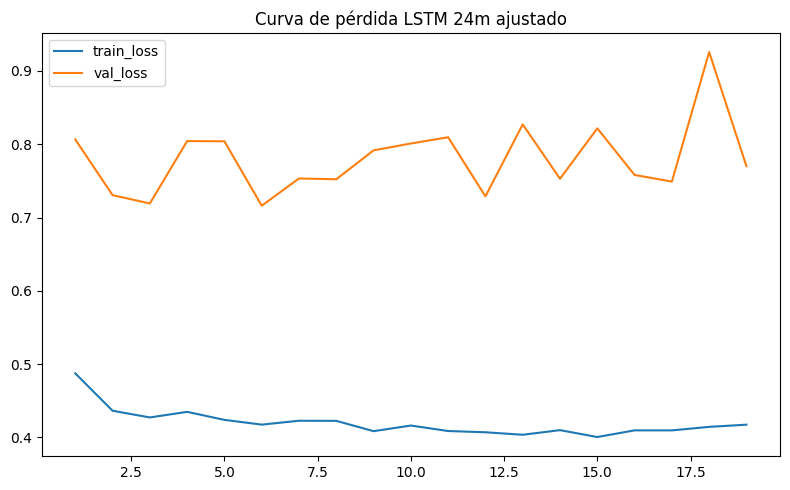

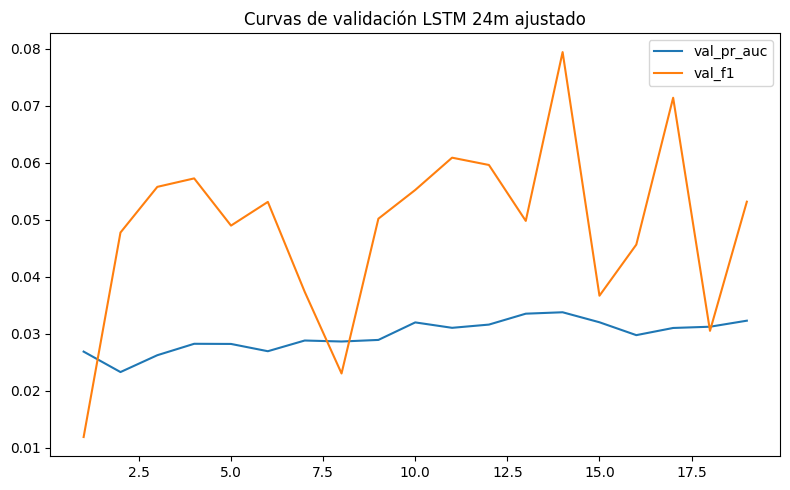


Proceso finalizado: modelo_lstm_24m_estacional_ajustado


In [45]:
import random
# =========================================================
# CONFIGURACION
# =========================================================
CARPETA_DATOS = "salidas_lstm_24m_estacional"
CARPETA_SALIDA = "modelo_lstm_24m_estacional_ajustado"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

SEED = 42
BATCH_SIZE = 100
EPOCHS = 30
LR = 4e-4
PATIENCE = 5
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================================================
# REPRODUCIBILIDAD
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# CARGA
# =========================================================
data = np.load(os.path.join(CARPETA_DATOS, "dataset_lstm_24m_estacional.npz"))

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

# =========================================================
# DATASET
# =========================================================
class SecuenciaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SecuenciaDataset(X_train, y_train)
val_ds = SecuenciaDataset(X_val, y_val)
test_ds = SecuenciaDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# =========================================================
# POS_WEIGHT
# =========================================================
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = min(max(neg / max(pos, 1), 1.0), 50.0)
print("pos_weight:", pos_weight)

# =========================================================
# MODELO
# =========================================================
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        logits = self.fc(h).squeeze(1)
        return logits

model = ModeloLSTM(
    input_size=X_train.shape[2],
    hidden_size=32,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =========================================================
# FUNCIONES
# =========================================================
def evaluar(loader, threshold=0.5):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)
            prob = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

def mejor_umbral(y_true, y_prob):
    mejor = {"umbral": 0.5, "f1": -1}
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {"umbral": float(t), "f1": float(f1)}
    return mejor

# =========================================================
# ENTRENAMIENTO
# =========================================================
history = []
best_val_pr_auc = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar(val_dl, threshold=0.5)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"]
    })

    print(
        f"Epoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(
            model.state_dict(),
            os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt")
        )
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print("Early stopping")
        break

# =========================================================
# EVALUACION FINAL
# =========================================================
model.load_state_dict(
    torch.load(
        os.path.join(CARPETA_SALIDA, "mejor_modelo_lstm_24m_ajustado.pt"),
        map_location=DEVICE
    )
)

val_final_raw = evaluar(val_dl, threshold=0.5)
umbral_optimo = mejor_umbral(val_final_raw["y_true"], val_final_raw["y_prob"])["umbral"]

val_final = evaluar(val_dl, threshold=umbral_optimo)
test_final = evaluar(test_dl, threshold=umbral_optimo)

print("\nMEJOR EPOCH:", best_epoch)
print("MEJOR VAL PR-AUC:", best_val_pr_auc)
print("UMBRAL OPTIMO:", umbral_optimo)

print("\nVALIDACION FINAL")
for k, v in val_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(val_final["matriz_confusion"]))

print("\nPRUEBA FINAL")
for k, v in test_final.items():
    if k not in ["y_true", "y_prob", "y_pred", "matriz_confusion"]:
        print(k, ":", v)
print("Matriz:\n", np.array(test_final["matriz_confusion"]))

# =========================================================
# GUARDAR
# =========================================================
hist = pd.DataFrame(history)
hist.to_csv(
    os.path.join(CARPETA_SALIDA, "historial_lstm_24m_ajustado.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.title("Curva de pérdida LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_loss_lstm_24m_ajustado.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_pr_auc"], label="val_pr_auc")
plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
plt.legend()
plt.title("Curvas de validación LSTM 24m ajustado")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_metricas_lstm_24m_ajustado.png"), dpi=200)
plt.show()

meta = {
    "seed": SEED,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "pos_weight": float(pos_weight),
    "best_epoch": best_epoch,
    "best_val_pr_auc": float(best_val_pr_auc),
    "umbral_optimo": float(umbral_optimo),
    "metricas_validacion_final": {
        k: v for k, v in val_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    },
    "metricas_prueba_final": {
        k: v for k, v in test_final.items()
        if k not in ["y_true", "y_prob", "y_pred"]
    }
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_lstm_24m_ajustado.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Resultado 20

- BATCH_SIZE = 100
- EPOCHS = 30
- LR = 4e-4
- PATIENCE = 5

PRUEBA FINAL
- loss : 0.5107730832916719
- roc_auc : 0.9136887072998324
- pr_auc : 0.08347059121630798
- brier : 0.011659491807222366
- precision : 0.08666666666666667
- recall : 0.3561643835616438
- f1 : 0.13941018766756033